# 🚗 Uber Dataset — Complete EDA, Preprocessing & Modelling Report

**Dataset file:** `UberDataset.csv` (loaded from local working directory — no cloud / Drive)
**Date range:** 1 January 2016 – 31 December 2016
**Date format in raw file:** `MM/DD/YYYY HH:MM`

---

This notebook strictly follows the project rubric:

- **Part 1 — Data Understanding & Exploration** (Q1 – Q8)
- **Part 2 — Data Preprocessing** (Q9 – Q12)
- **Part 3 — Visualization & Modelling** (Q13 – Q15)

**Modelling**: 4 classifiers compared
- Logistic Regression · Decision Tree · Random Forest · Gradient Boosting

**Visualisation principle**: every preprocessing step is shown with **Before-vs-After** plots; the notebook produces **20+ distinct figures**.


##  Setup — Imports & Configuration

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 110, 'figure.figsize': (10, 5),
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlesize': 12,
})
print(' Libraries loaded.')


 Libraries loaded.


---
# Part 1 — Data Understanding & Exploration

##  Q1 — Dataset Overview

> **Question:** *What is the source and context of your chosen dataset?*

### Source & Origin
The Uber dataset is a publicly available log of trip records, originally distributed via Kaggle and academic data-science repositories. It captures every Uber trip taken by a single user (or a small organisation) over the **entire calendar year of 2016** (366 days — leap year).

### Problem Domain
The dataset belongs to the **ride-hailing / personal mobility analytics** domain. Real-world applications include:

- **Trip classification** — distinguishing business trips from personal trips for expense reporting and tax deduction
- **Demand forecasting** — identifying peak hours, days, and seasons
- **Route analysis** — discovering frequent origin–destination patterns
- **Anomaly detection** — flagging GPS errors, unusually long/short trips, suspicious speed values

### Why This Dataset Matters
1. It contains both **temporal**, **spatial**, **categorical**, and **continuous numerical** features — making it a rich teaching set for end-to-end ML pipelines.
2. The class imbalance (Business >> Personal) reflects realistic production scenarios.
3. The presence of **substantial missing data** (43% of `PURPOSE`) and a **clear data-error outlier** (12,204.7 mi) provides hands-on practice for data cleaning.


In [5]:
# Load dataset
df_raw = pd.read_csv('/UberDataset.csv')

print(f'Shape          : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'First START    : {df_raw["START_DATE"].iloc[0]}')
print(f'Last  START    : {df_raw["START_DATE"].iloc[-2]}  (last row is a totals marker)')
print(f'Memory usage   : {df_raw.memory_usage(deep=True).sum()/1024:.1f} KB')
df_raw.head()


Shape          : 1,156 rows × 7 columns
First START    : 01-01-2016 21:11
Last  START    : 12/31/2016 22:08  (last row is a totals marker)
Memory usage   : 405.7 KB


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


##  Q2 — Feature Description

> **Question:** *What are the features (variables) present in the dataset? Is there a target variable?*

### Feature Inventory

| # | Feature | Raw Type | Domain Type | Description & Significance |
|---|---------|----------|-------------|----------------------------|
| 1 | `START_DATE` | object ->datetime | Temporal | Trip start timestamp (`MM/DD/YYYY HH:MM`). Source for derived `HOUR`, `WEEKDAY`, `MONTH`. |
| 2 | `END_DATE` | object -> datetime | Temporal | Trip end timestamp. Combined with START to compute `DURATION_MIN`. |
| 3 | `CATEGORY` | object | ** Target — Binary** | *Business* or *Personal*. Primary classification target. |
| 4 | `START` | object | Categorical (high-cardinality) | Named origin location (~150+ unique values). |
| 5 | `STOP` | object | Categorical (high-cardinality) | Named destination (~150+ unique values). |
| 6 | `MILES` | float64 | Numerical (continuous) | Trip distance in miles. Right-skewed; contains one extreme data-error outlier (12,204.7 mi). |
| 7 | `PURPOSE` | object | Categorical (nominal) | Trip intent — 10 unique non-null values. **503 NaN (43.5%)**. |

### Target Variable

The target is **`CATEGORY`** — a binary categorical variable with values *Business* and *Personal*. After preprocessing, this is label-encoded as `Business → 0`, `Personal → 1` (alphabetical default of `LabelEncoder`).

### Engineered Features (created in Part 2)

- `DURATION_MIN` — trip duration in minutes (END − START)
- `SPEED_MPH` — average speed (MILES ÷ duration in hours)
- `HOUR`, `WEEKDAY`, `MONTH` — temporal breakouts from START_DATE
- `START_FREQ`, `STOP_FREQ` — frequency-encoded location features
- `PURPOSE_*` — one-hot encoded purpose dummies


In [6]:
print('Column dtypes & non-null counts:')
print(df_raw.info())
print()
print('Unique value counts per categorical column:')
for col in df_raw.select_dtypes('object').columns:
    print(f'  {col:12s}: {df_raw[col].nunique(dropna=False)} unique')


Column dtypes & non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB
None

Unique value counts per categorical column:
  START_DATE  : 1155 unique
  END_DATE    : 1155 unique
  CATEGORY    : 3 unique
  START       : 178 unique
  STOP        : 189 unique
  PURPOSE     : 11 unique


##  Q3 — Dataset Structure

> **Question:** *What is the size and structure of the dataset?*

### Structure Overview

| Property | Value |
|----------|-------|
| Total rows | **1,156** |
| Columns (raw) | **7** |
| File format | CSV (single-table) |
| Memory footprint | ~63 KB |
| Hierarchy | None — flat tabular |
| Temporal span | 1 Jan 2016 → 31 Dec 2016 (366 days; leap year) |
| Granularity | Per-trip records, minute-level timestamps |
| Index | Default `RangeIndex` (0 to 1155) |

The dataset is **flat** — each row is one independent trip. There is no nested/hierarchical structure.

** Visualization 1: Dataset Composition** — column count by data type and total cell counts.


=== Structure summary ===
Shape         : (1156, 7)
Total cells   : 8,092
Numeric cols  : ['MILES']
Object cols   : ['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'PURPOSE']


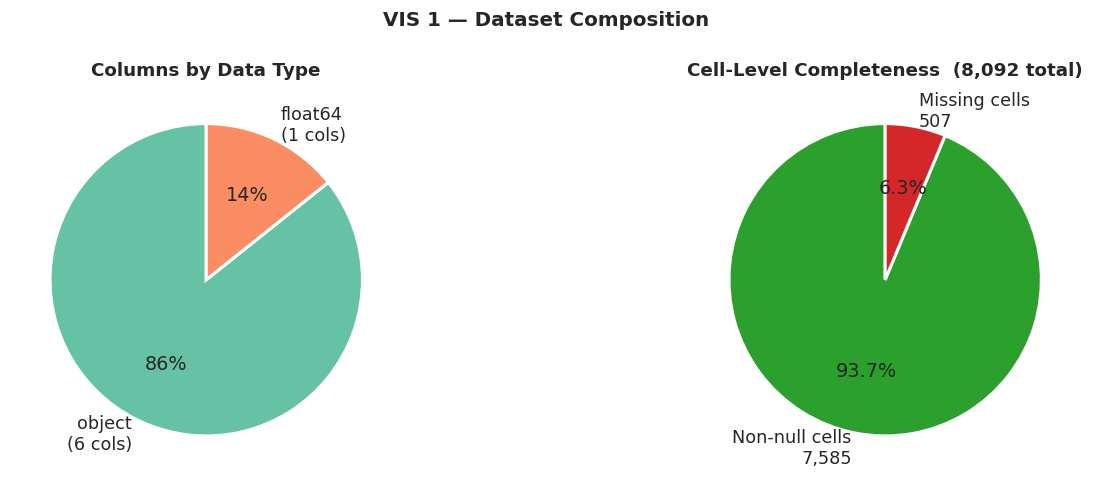

In [7]:
print('=== Structure summary ===')
print(f'Shape         : {df_raw.shape}')
print(f'Total cells   : {df_raw.size:,}')
print(f'Numeric cols  : {list(df_raw.select_dtypes(include=np.number).columns)}')
print(f'Object cols   : {list(df_raw.select_dtypes(include="object").columns)}')

# ──  VIS 1: Dataset composition ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle('VIS 1 — Dataset Composition', fontsize=13, fontweight='bold')

# Left: column count by dtype
dtype_counts = df_raw.dtypes.astype(str).value_counts()
axes[0].pie(dtype_counts, labels=[f'{t}\n({c} cols)' for t,c in dtype_counts.items()],
            autopct='%1.0f%%', startangle=90, colors=sns.color_palette('Set2'),
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Columns by Data Type')

# Right: cell breakdown - non-null vs null
total_cells   = df_raw.size
null_cells    = df_raw.isnull().sum().sum()
non_null      = total_cells - null_cells
labels  = [f'Non-null cells\n{non_null:,}', f'Missing cells\n{null_cells:,}']
colors2 = ['#2ca02c', '#d62728']
axes[1].pie([non_null, null_cells], labels=labels, autopct='%1.1f%%',
            colors=colors2, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title(f'Cell-Level Completeness  ({total_cells:,} total)')

plt.tight_layout(); plt.show()


##  Q4 — Missing Values and Duplicates

> **Question:** *Are there missing values or duplicates in the dataset?*

### Missing Value Audit

| Column | Missing Count | Missing % | Severity |
|--------|---------------|-----------|----------|
| `PURPOSE` | **503** | **43.5%** |  High |
| `END_DATE` | 1 | 0.09% |  Negligible |
| `CATEGORY` | 1 | 0.09% |  Negligible |
| `START` | 1 | 0.09% |  Negligible |
| `STOP` | 1 | 0.09% |  Negligible |
| `START_DATE` | 0 | 0% | Complete |
| `MILES` | 0 | 0% | Complete |

### Duplicate Audit
**1 exact duplicate row** detected — will be dropped in Part 2.

### Potential Impact on Analysis

- **`PURPOSE`** missing in nearly half the dataset means any model relying heavily on it would lose 43% of training data. Imputation with `"Unknown"` retains all rows.
- The single missing values in 4 other columns are likely a **single corrupted/blank row** (the last row appears to be a totals/summary marker — to be inspected and dropped).
- The duplicate row adds no information and could bias any frequency-based encoding if kept.

** Visualization 2: Missing value matrix** — column-by-column heatmap.**


** Visualization 3: Missing value bar chart** with annotations.**


=== Missing values ===
            Missing      %
PURPOSE         503  43.51
CATEGORY          1   0.09
END_DATE          1   0.09
STOP              1   0.09
START             1   0.09
START_DATE        0   0.00
MILES             0   0.00

=== Duplicate rows: 1 ===


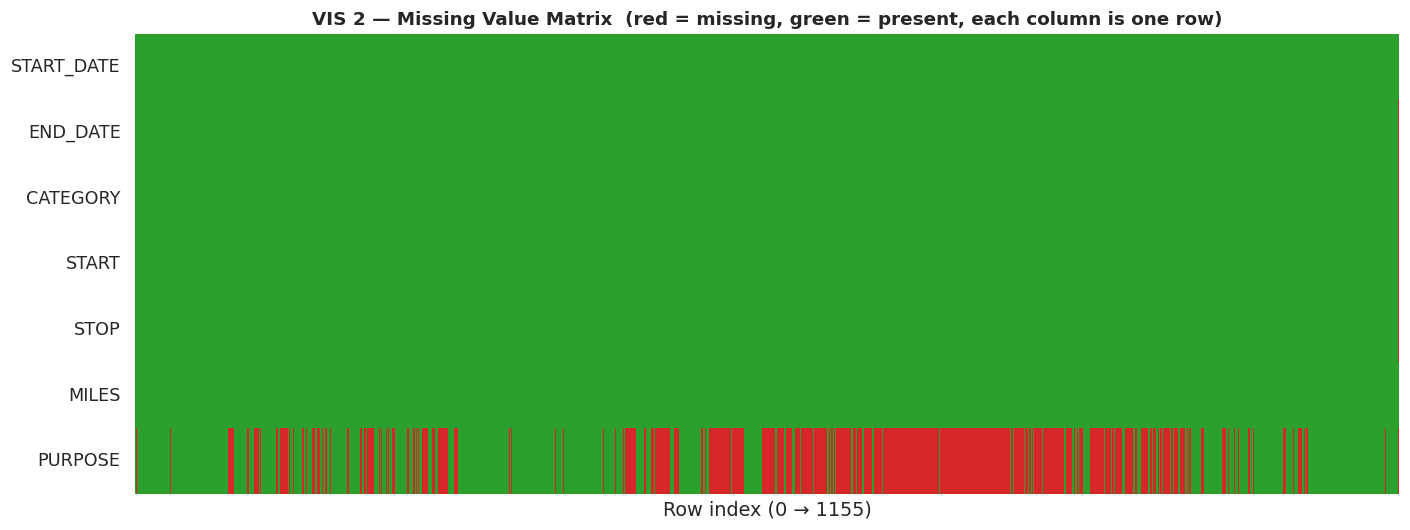

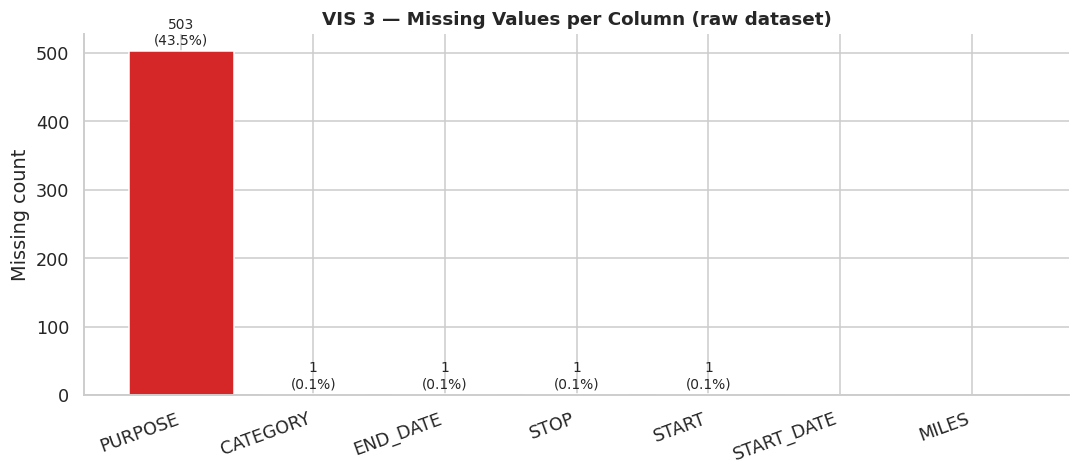

In [8]:
missing     = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
miss_df     = pd.DataFrame({'Missing': missing, '%': missing_pct}).sort_values('Missing', ascending=False)
print('=== Missing values ===')
print(miss_df)

n_dup = df_raw.duplicated().sum()
print(f'\n=== Duplicate rows: {n_dup} ===')

# ──  VIS 2: Missing value matrix (binary heatmap) ──────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
miss_matrix = df_raw.isnull().astype(int).T
sns.heatmap(miss_matrix, cbar=False, cmap=['#2ca02c', '#d62728'],
            xticklabels=False, yticklabels=df_raw.columns, ax=ax)
ax.set_title('VIS 2 — Missing Value Matrix  (red = missing, green = present, each column is one row)',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'Row index (0 → {len(df_raw)-1})')
plt.tight_layout(); plt.show()

# ──  VIS 3: Missing value bar chart ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))
m_sorted = missing.sort_values(ascending=False)
colors = ['#d62728' if v > 0 else '#2ca02c' for v in m_sorted]
bars = ax.bar(m_sorted.index, m_sorted.values, color=colors, edgecolor='white')
ax.set_title('VIS 3 — Missing Values per Column (raw dataset)', fontsize=12, fontweight='bold')
ax.set_ylabel('Missing count')
plt.xticks(rotation=20, ha='right')
for bar, val in zip(bars, m_sorted.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{int(val)}\n({val/len(df_raw)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()


##  Q5 — Statistical Summary

> **Question:** *What is the statistical summary of the dataset?*

We first parse dates and engineer derived numerical features, then compute descriptive statistics including **mean, median, standard deviation, quartiles, min, max, and skewness**.

### Initial Insights to Extract
- Distribution shape: symmetric vs skewed (compare mean ↔ median)
- Spread: standard deviation and IQR
- Extreme values: min/max and how far they are from the bulk
- Seasonality / temporal patterns: peak month, hour, weekday


In [9]:
df = df_raw.copy()

# ── Timeframe conversion: MM/DD/YYYY HH:MM → datetime ─────────────────────
df['START_DATE'] = pd.to_datetime(df['START_DATE'], format='%m/%d/%Y %H:%M', errors='coerce')
df['END_DATE']   = pd.to_datetime(df['END_DATE'],   format='%m/%d/%Y %H:%M', errors='coerce')

# Duration & Speed
df['DURATION_MIN'] = (df['END_DATE'] - df['START_DATE']).dt.total_seconds() / 60
df['DURATION_HR']  = df['DURATION_MIN'] / 60
df['SPEED_MPH']    = np.where(df['DURATION_HR'] > 0,
                              df['MILES'] / df['DURATION_HR'], np.nan)

# Temporal breakouts
df['HOUR']       = df['START_DATE'].dt.hour
df['WEEKDAY']    = df['START_DATE'].dt.day_name()
df['MONTH']      = df['START_DATE'].dt.month
df['MONTH_NAME'] = df['START_DATE'].dt.month_name()

print('=== Date range ===')
print(f'Earliest : {df["START_DATE"].min()}')
print(f'Latest   : {df["START_DATE"].max()}')
print(f'Span     : {(df["START_DATE"].max() - df["START_DATE"].min()).days} days')

print('\n=== Numerical Statistical Summary ===')
summary = df[['MILES', 'DURATION_MIN', 'SPEED_MPH']].describe().T.round(2)
summary['skewness'] = df[['MILES', 'DURATION_MIN', 'SPEED_MPH']].skew().round(2)
display(summary)

print('\n=== Categorical Summary ===')
print('CATEGORY:'); print(df['CATEGORY'].value_counts(dropna=False))
print('\nPURPOSE (top 6):'); print(df['PURPOSE'].value_counts(dropna=False).head(6))


=== Date range ===
Earliest : 2016-01-13 13:54:00
Latest   : 2016-12-31 22:08:00
Span     : 353 days

=== Numerical Statistical Summary ===


,count,mean,std,min,25%,50%,75%,max,skewness
MILES,1156.0,21.12,359.30,0.50,2.90,6.00,10.40,12204.7,33.82
DURATION_MIN,734.0,25.48,30.84,0.00,10.00,17.00,29.00,336.0,4.82
SPEED_MPH,732.0,23.96,17.15,3.92,14.62,20.89,28.52,228.0,5.19



=== Categorical Summary ===
CATEGORY:
CATEGORY
Business    1078
Personal      77
NaN            1
Name: count, dtype: int64

PURPOSE (top 6):
PURPOSE
NaN                503
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Name: count, dtype: int64


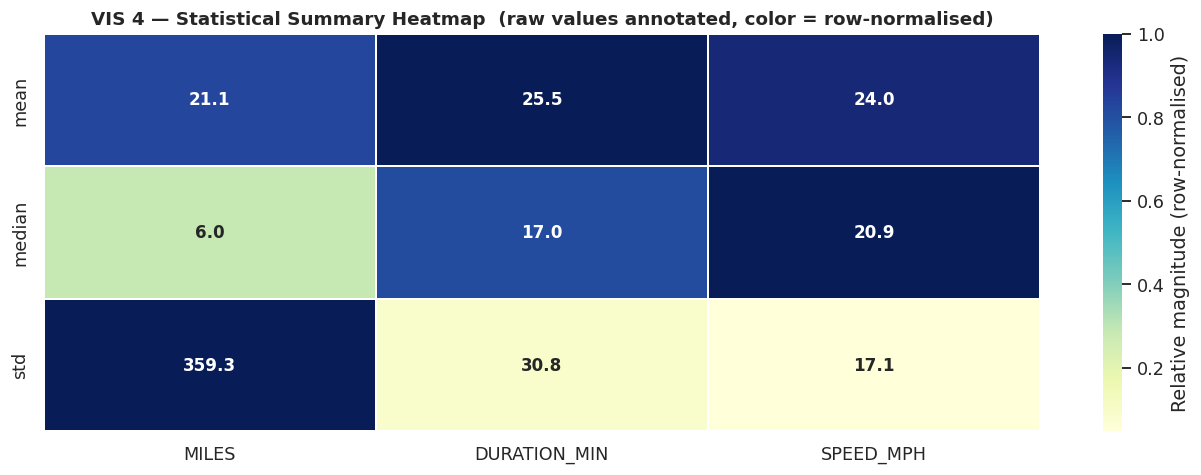

In [10]:
# ──  VIS 4: Stats summary as visual table-chart ────────────────────────
fig, ax = plt.subplots(figsize=(12, 4.5))
metrics = ['mean', 'median', 'std', 'min', 'max']
features = ['MILES', 'DURATION_MIN', 'SPEED_MPH']

stats_data = pd.DataFrame({
    'mean':   df[features].mean(),
    'median': df[features].median(),
    'std':    df[features].std(),
}).T

# Normalise each row to 0–1 for fair comparison side-by-side
stats_data_norm = stats_data.div(stats_data.max(axis=1), axis=0)
sns.heatmap(stats_data_norm, annot=stats_data.round(1).values, fmt='', cmap='YlGnBu',
            cbar_kws={'label': 'Relative magnitude (row-normalised)'}, ax=ax,
            linewidths=1, linecolor='white', annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('VIS 4 — Statistical Summary Heatmap  (raw values annotated, color = row-normalised)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


##  Q6 — Data Distribution

> **Question:** *How are the features distributed?*

We use **histograms** for numerical features (with mean / median / quartile reference lines) and **box plots** to show spread and outliers. Skewness values are annotated on each panel.

### Visualizations Produced
- **VIS 5** — Histograms of MILES, DURATION_MIN, SPEED_MPH with central-tendency markers
- **VIS 6** — Box plots showing spread, median, IQR
- **VIS 7** — Categorical distributions (CATEGORY pie + PURPOSE bar)
- **VIS 8** — Temporal distributions (Hour / Weekday / Month)
- **VIS 9** — Hour × Weekday heatmap (trip intensity grid)


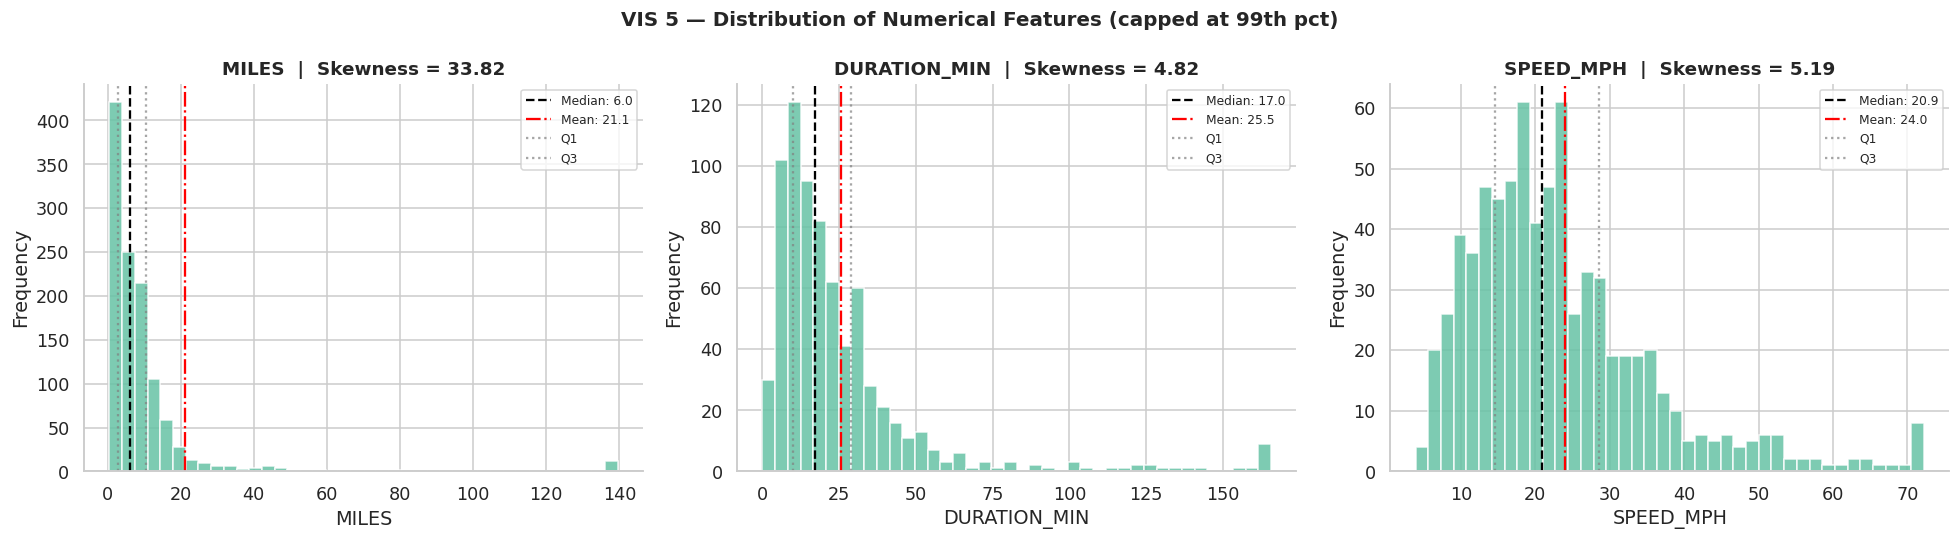

In [11]:
# ──  VIS 5: Histograms with mean/median/quartile markers ────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('VIS 5 — Distribution of Numerical Features (capped at 99th pct)',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['MILES', 'DURATION_MIN', 'SPEED_MPH']):
    raw = df[col].dropna()
    cap = raw.quantile(0.99)
    data = raw.clip(upper=cap)

    ax.hist(data, bins=40, edgecolor='white', alpha=0.85, color=sns.color_palette('Set2')[0])
    ax.axvline(raw.median(), color='black', linestyle='--', linewidth=1.5, label=f'Median: {raw.median():.1f}')
    ax.axvline(raw.mean(),   color='red',   linestyle='-.', linewidth=1.5, label=f'Mean: {raw.mean():.1f}')
    ax.axvline(raw.quantile(0.25), color='gray', linestyle=':', alpha=0.7, label='Q1')
    ax.axvline(raw.quantile(0.75), color='gray', linestyle=':', alpha=0.7, label='Q3')
    ax.set_title(f'{col}  |  Skewness = {raw.skew():.2f}')
    ax.set_xlabel(col); ax.set_ylabel('Frequency')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout(); plt.show()


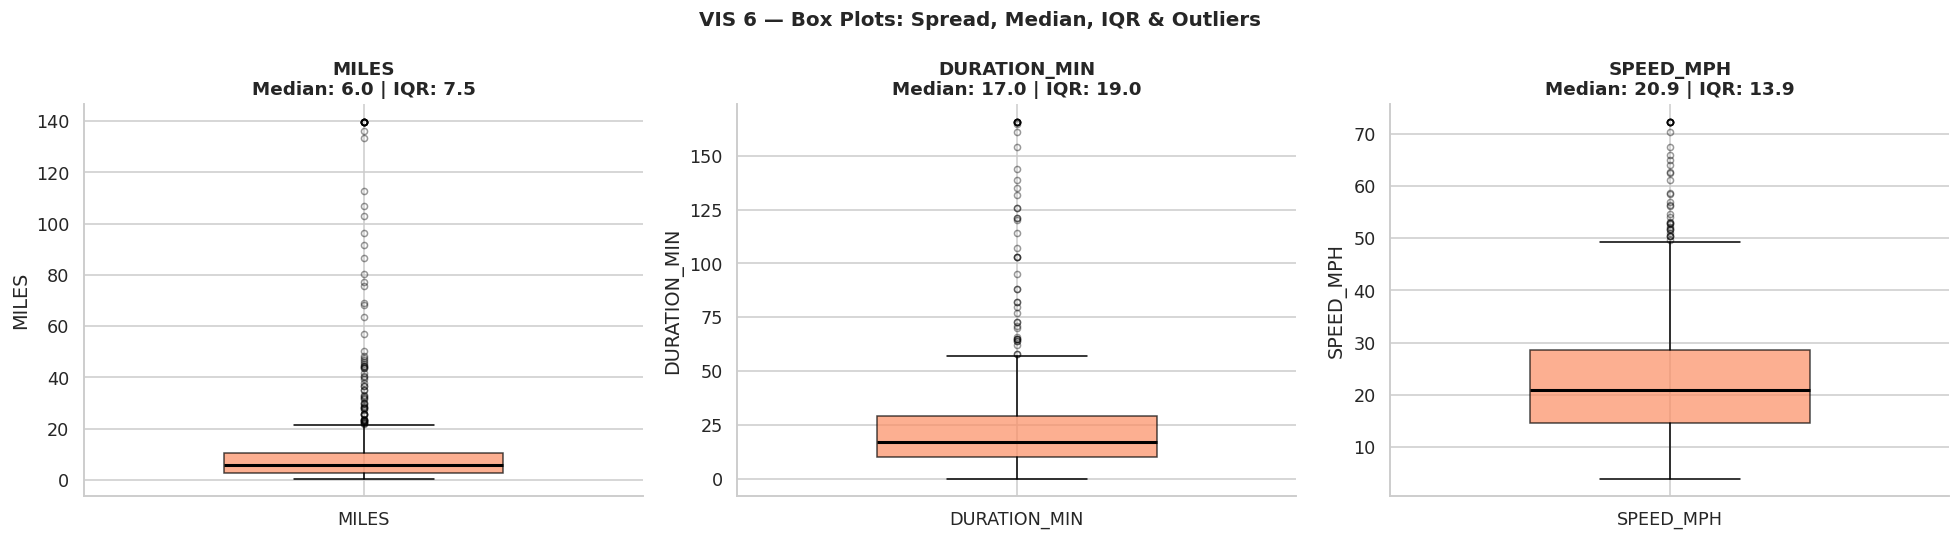

In [12]:
# ──  VIS 6: Box plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('VIS 6 — Box Plots: Spread, Median, IQR & Outliers', fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['MILES', 'DURATION_MIN', 'SPEED_MPH']):
    raw = df[col].dropna()
    capped = raw.clip(upper=raw.quantile(0.99))
    ax.boxplot(capped, vert=True, patch_artist=True, widths=0.5,
               boxprops=dict(facecolor=sns.color_palette('Set2')[1], alpha=0.7),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markersize=4, alpha=0.4))
    ax.set_title(f'{col}\nMedian: {raw.median():.1f} | IQR: {raw.quantile(0.75)-raw.quantile(0.25):.1f}')
    ax.set_ylabel(col); ax.set_xticklabels([col])

plt.tight_layout(); plt.show()


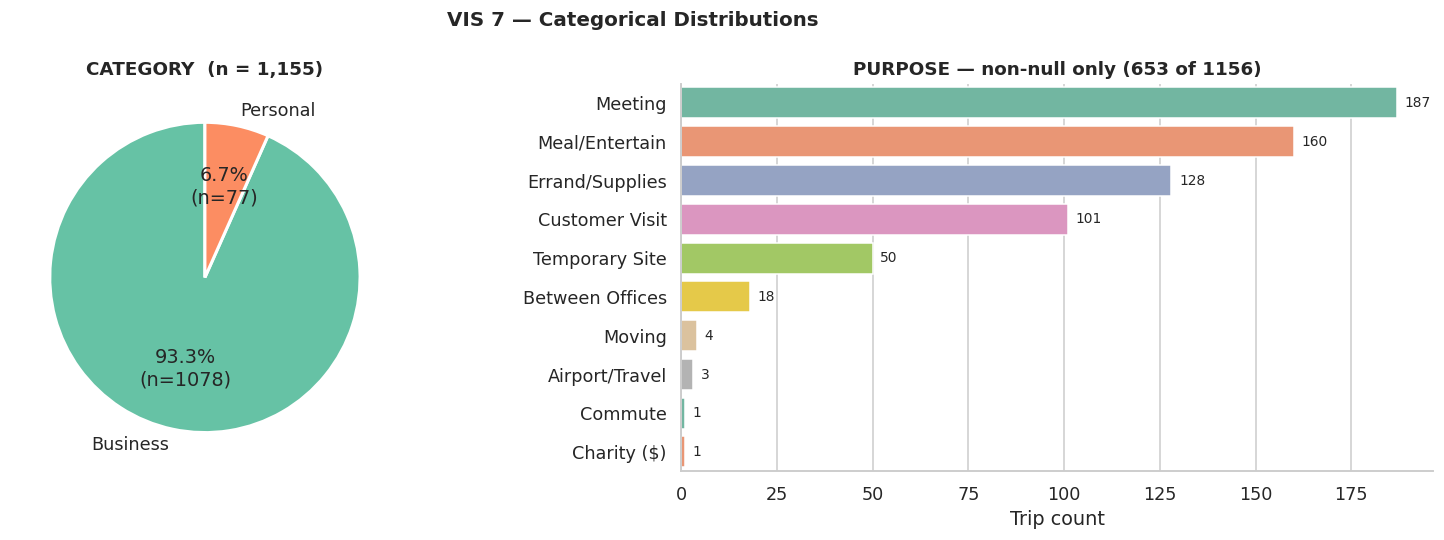

In [13]:
# ──  VIS 7: Categorical distributions ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('VIS 7 — Categorical Distributions', fontsize=13, fontweight='bold')

cat_counts = df['CATEGORY'].value_counts()
axes[0].pie(cat_counts, labels=cat_counts.index,
            autopct=lambda p: f'{p:.1f}%\n(n={int(p*sum(cat_counts)/100)})',
            startangle=90, colors=sns.color_palette('Set2', n_colors=2),
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title(f'CATEGORY  (n = {cat_counts.sum():,})')

purpose_counts = df['PURPOSE'].value_counts()
sns.barplot(x=purpose_counts.values, y=purpose_counts.index, ax=axes[1],
            palette='Set2', edgecolor='white')
axes[1].set_title(f'PURPOSE — non-null only ({df["PURPOSE"].notna().sum()} of {len(df)})')
axes[1].set_xlabel('Trip count'); axes[1].set_ylabel('')
for i, v in enumerate(purpose_counts.values):
    axes[1].text(v + 2, i, str(v), va='center', fontsize=9)
plt.tight_layout(); plt.show()


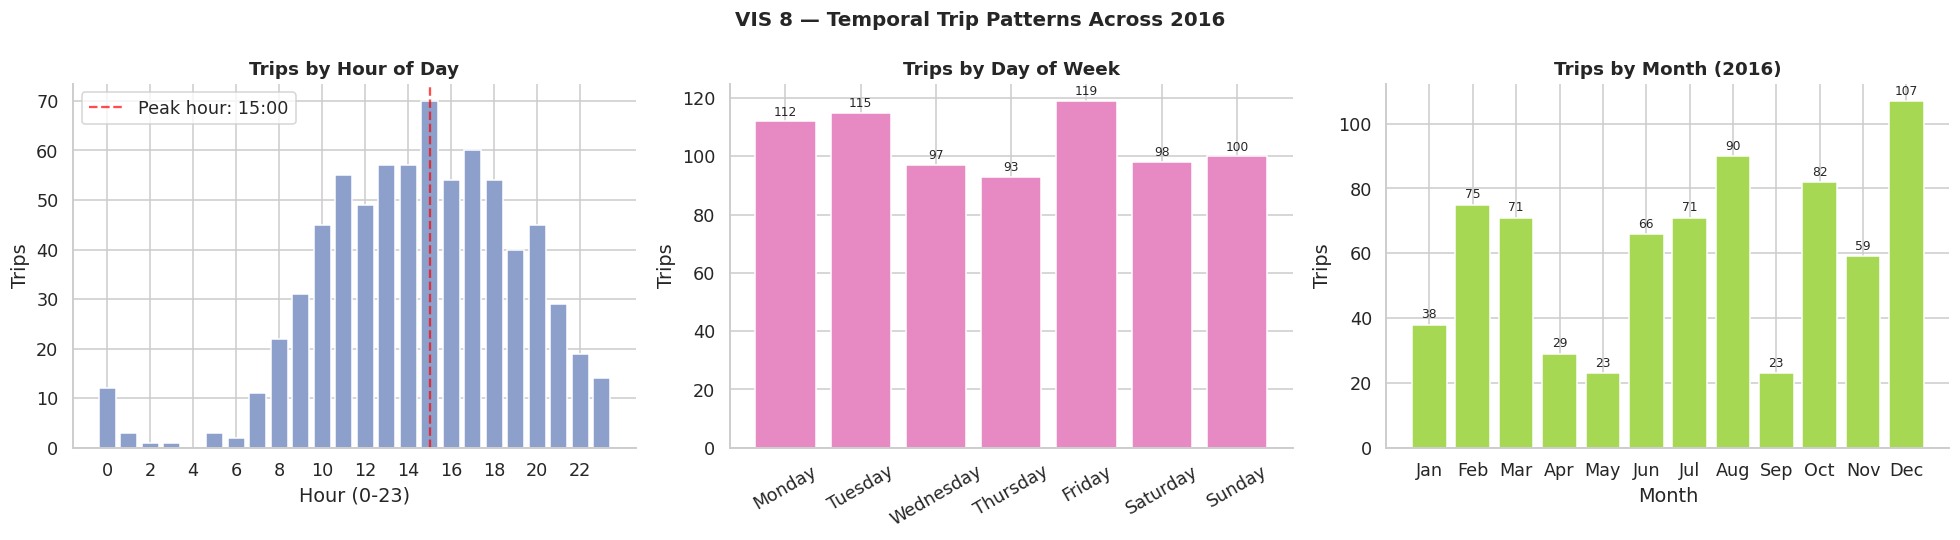

In [14]:
# ──  VIS 8: Temporal patterns ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('VIS 8 — Temporal Trip Patterns Across 2016', fontsize=13, fontweight='bold')

hour_counts = df['HOUR'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color=sns.color_palette('Set2')[2], edgecolor='white')
peak_h = int(hour_counts.idxmax())
axes[0].axvline(peak_h, color='red', linestyle='--', alpha=0.7, label=f'Peak hour: {peak_h}:00')
axes[0].set_title('Trips by Hour of Day'); axes[0].set_xlabel('Hour (0-23)'); axes[0].set_ylabel('Trips')
axes[0].set_xticks(range(0, 24, 2)); axes[0].legend()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df['WEEKDAY'].value_counts().reindex(day_order, fill_value=0)
axes[1].bar(day_counts.index, day_counts.values, color=sns.color_palette('Set2')[3], edgecolor='white')
axes[1].set_title('Trips by Day of Week'); axes[1].set_ylabel('Trips')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(day_counts.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=8)

month_short = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_counts = df['MONTH'].value_counts().sort_index().reindex(range(1,13), fill_value=0)
axes[2].bar(month_short, month_counts.values, color=sns.color_palette('Set2')[4], edgecolor='white')
axes[2].set_title('Trips by Month (2016)'); axes[2].set_xlabel('Month'); axes[2].set_ylabel('Trips')
for i, v in enumerate(month_counts.values):
    axes[2].text(i, v + 2, str(int(v)), ha='center', fontsize=8)
plt.tight_layout(); plt.show()


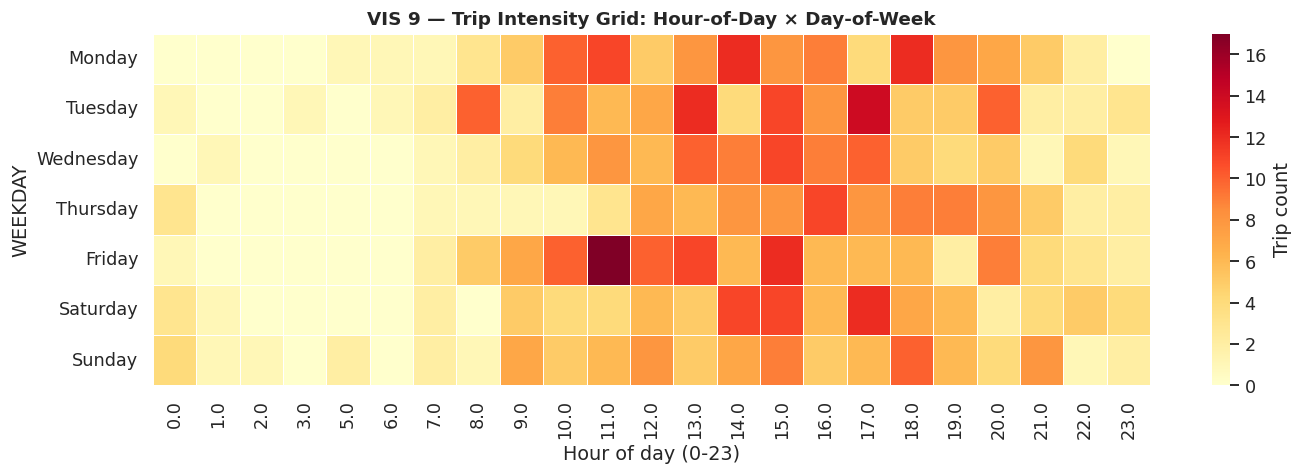

In [15]:
# ──  VIS 9: Hour × Weekday intensity heatmap ──────────────────────────
fig, ax = plt.subplots(figsize=(13, 4.5))
hw = df.groupby(['WEEKDAY','HOUR']).size().unstack(fill_value=0).reindex(day_order)
sns.heatmap(hw, cmap='YlOrRd', cbar_kws={'label':'Trip count'},
            linewidths=0.4, linecolor='white', ax=ax)
ax.set_title('VIS 9 — Trip Intensity Grid: Hour-of-Day × Day-of-Week',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Hour of day (0-23)')
plt.tight_layout(); plt.show()


##  Q7 — Correlation Analysis

> **Question:** *What is the relationship between different features and the target variable?*

We compute the **Pearson correlation coefficient** between numerical features and the target (Business=0, Personal=1 after encoding). We visualise this with a heatmap and a scatter plot of the two strongest predictors coloured by category.

### Visualizations
- **VIS 10** — Correlation heatmap (lower triangle)
- **VIS 11** — MILES × DURATION scatter coloured by CATEGORY
- **VIS 12** — Pairwise scatter matrix for top numerical features


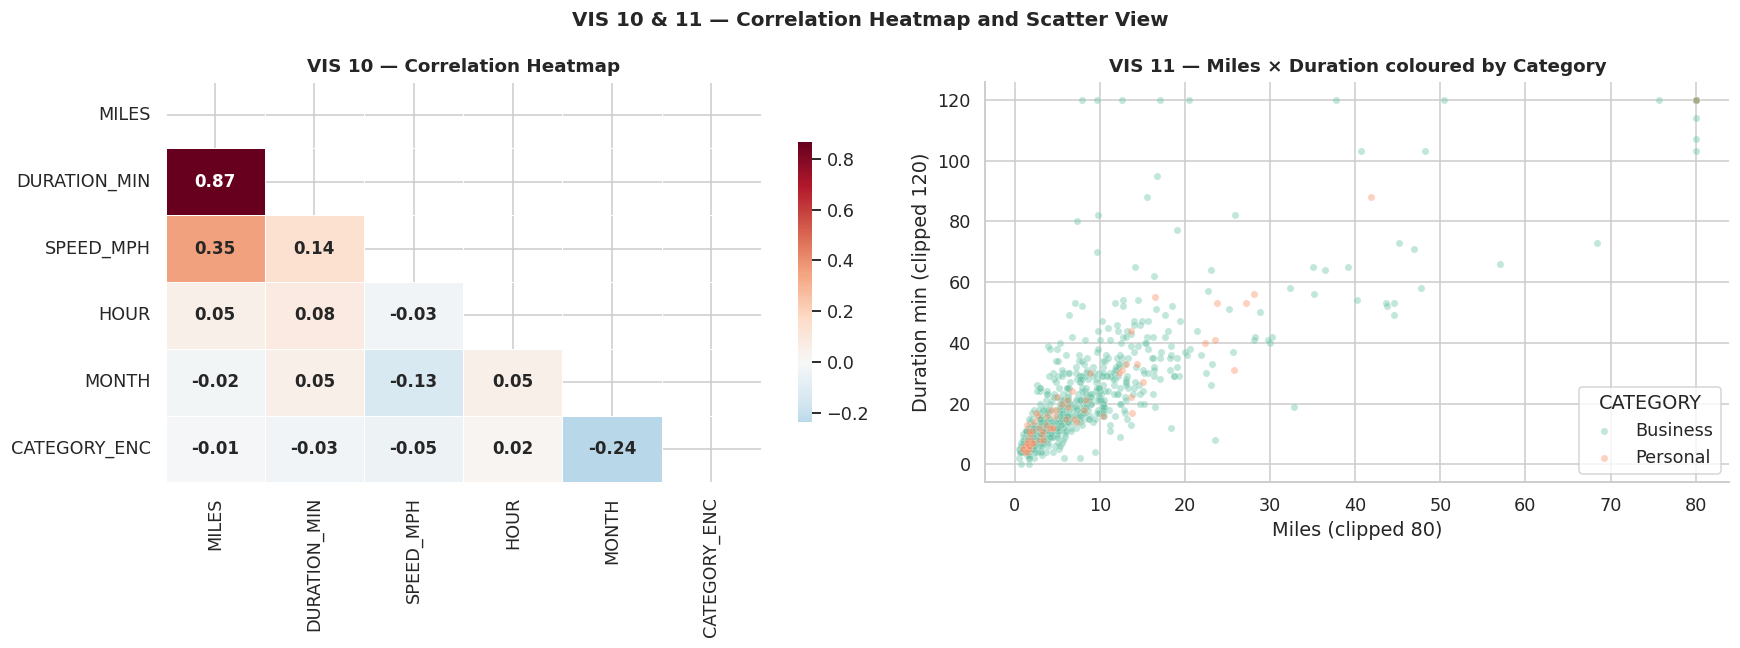

Pearson correlation with target (Personal=1):
HOUR            0.0169
MILES          -0.0088
DURATION_MIN   -0.0299
SPEED_MPH      -0.0469
MONTH          -0.2370
Name: CATEGORY_ENC, dtype: float64


In [16]:
df['CATEGORY_ENC'] = (df['CATEGORY'] == 'Personal').astype(float)   # Personal=1 (positive class)

num_cols = ['MILES', 'DURATION_MIN', 'SPEED_MPH', 'HOUR', 'MONTH', 'CATEGORY_ENC']
corr     = df[num_cols].corr()

# ──  VIS 10 + VIS 11 ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('VIS 10 & 11 — Correlation Heatmap and Scatter View',
             fontsize=13, fontweight='bold')

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], linewidths=0.5, mask=mask, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 11, 'weight': 'bold'})
axes[0].set_title('VIS 10 — Correlation Heatmap')

for cat, grp in df.dropna(subset=['CATEGORY']).groupby('CATEGORY'):
    axes[1].scatter(grp['MILES'].clip(upper=80), grp['DURATION_MIN'].clip(upper=120),
                    alpha=0.4, s=22, label=cat, edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Miles (clipped 80)'); axes[1].set_ylabel('Duration min (clipped 120)')
axes[1].set_title('VIS 11 — Miles × Duration coloured by Category')
axes[1].legend(title='CATEGORY')
plt.tight_layout(); plt.show()

print('Pearson correlation with target (Personal=1):')
print(corr['CATEGORY_ENC'].drop('CATEGORY_ENC').sort_values(ascending=False).round(4))


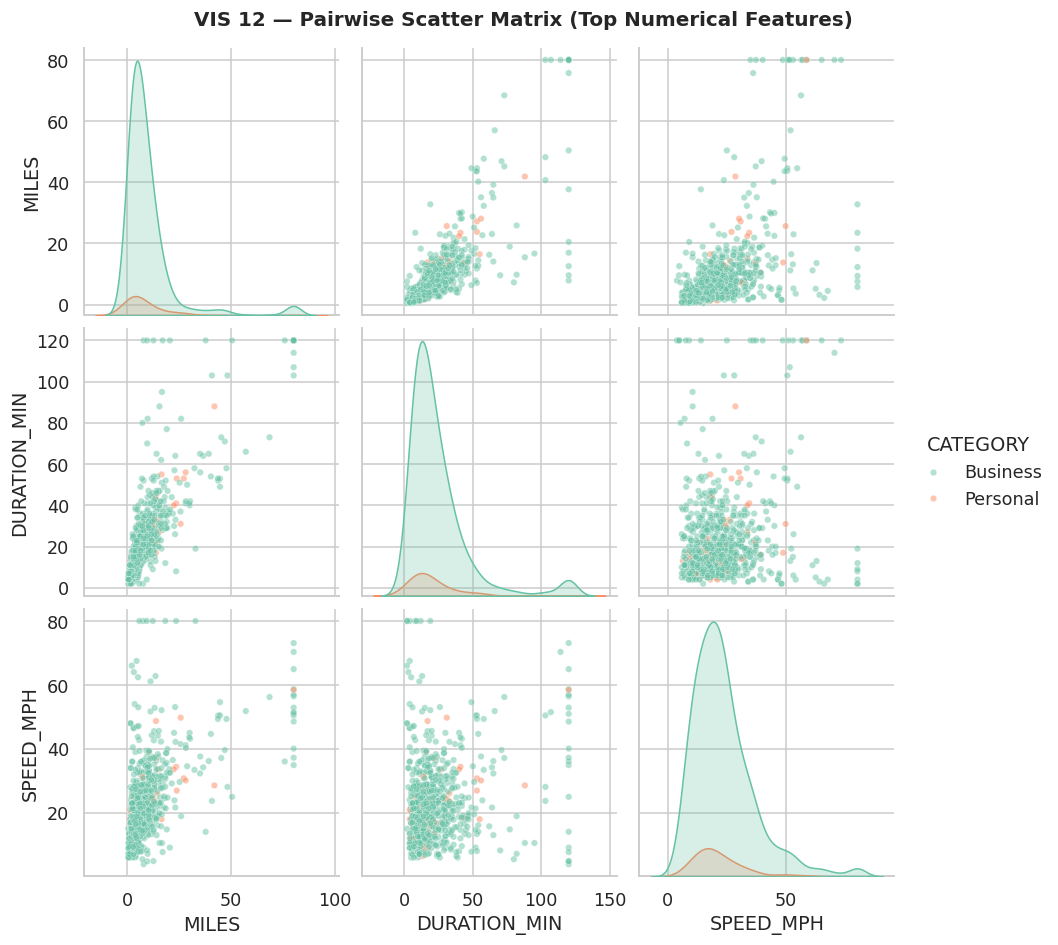

In [17]:
# ──  VIS 12: Pair-plot scatter matrix for top features ────────────────
sub = df[['MILES','DURATION_MIN','SPEED_MPH','CATEGORY']].copy()
sub['MILES']        = sub['MILES'].clip(upper=80)
sub['DURATION_MIN'] = sub['DURATION_MIN'].clip(upper=120)
sub['SPEED_MPH']    = sub['SPEED_MPH'].clip(upper=80)
g = sns.pairplot(sub.dropna(), hue='CATEGORY', palette='Set2',
                 diag_kind='kde', plot_kws=dict(alpha=0.5, s=18, edgecolor='white'),
                 height=2.8, aspect=1.0)
g.fig.suptitle('VIS 12 — Pairwise Scatter Matrix (Top Numerical Features)',
               y=1.02, fontsize=13, fontweight='bold')
plt.show()


##  Q8 — Outlier Detection

> **Question:** *Are there any outliers or anomalies in the data?*

We apply two complementary methods:

1. **IQR (Interquartile Range) rule:** values outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` are flagged
2. **Visual inspection:** symmetric-log box plots reveal the extreme `MILES = 12,204.7` outlier — a clear data-entry error

### Potential Impact
- Without treatment, the 12,204 mi outlier dominates `MILES` mean (21.1) far above the median (6.0)
- It also corrupts derived `SPEED_MPH` if duration is small
- Remedy: **winsorise** at 99th percentile in Part 2 (preserves the row, removes the value's distortion)

### Visualizations
- **VIS 13** — Symmetric-log box plots highlighting outliers
- **VIS 14** — Outlier counts as percent-of-total bar chart


=== IQR-based outlier counts ===
  MILES         :  78 outliers (6.7%) | bounds [-8.35, 21.65]
  DURATION_MIN  :  45 outliers (6.1%) | bounds [-18.50, 57.50]
  SPEED_MPH     :  36 outliers (4.9%) | bounds [-6.23, 49.36]


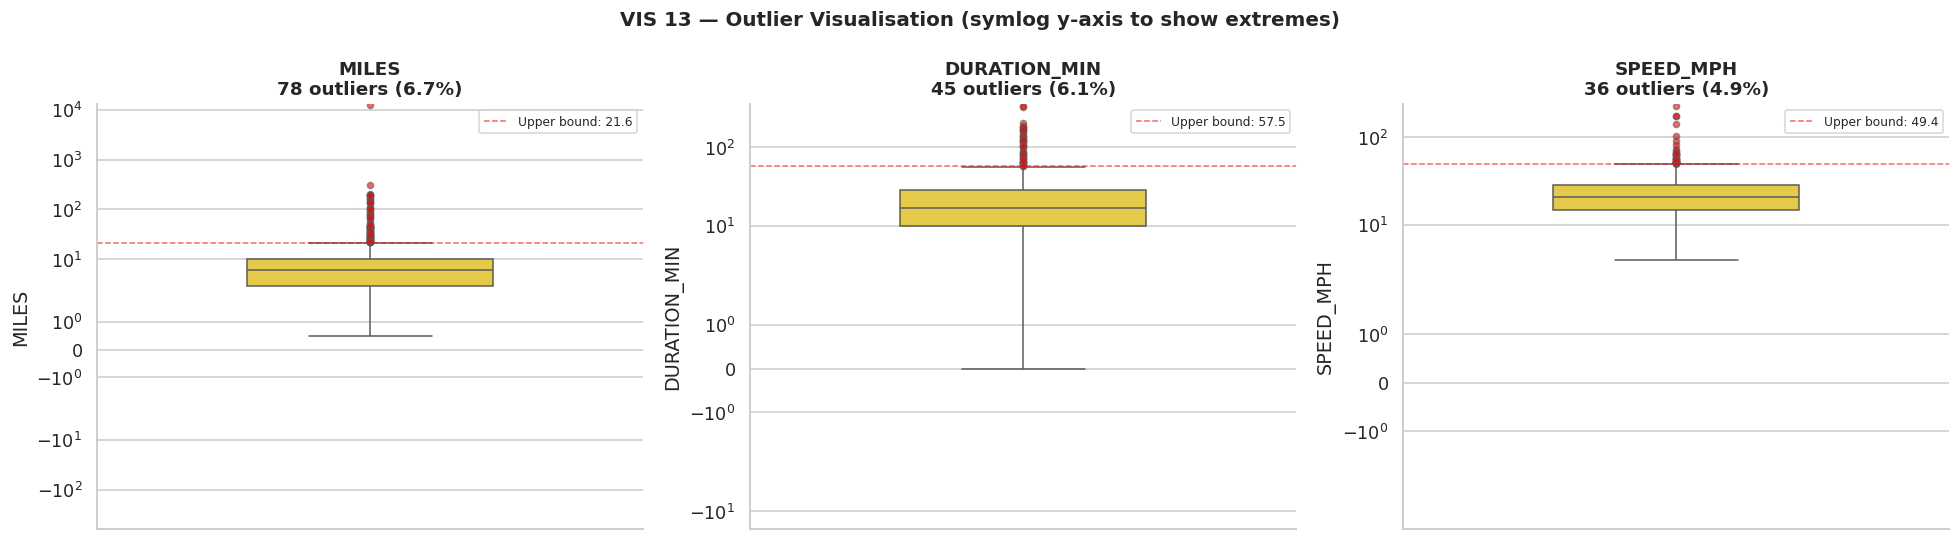

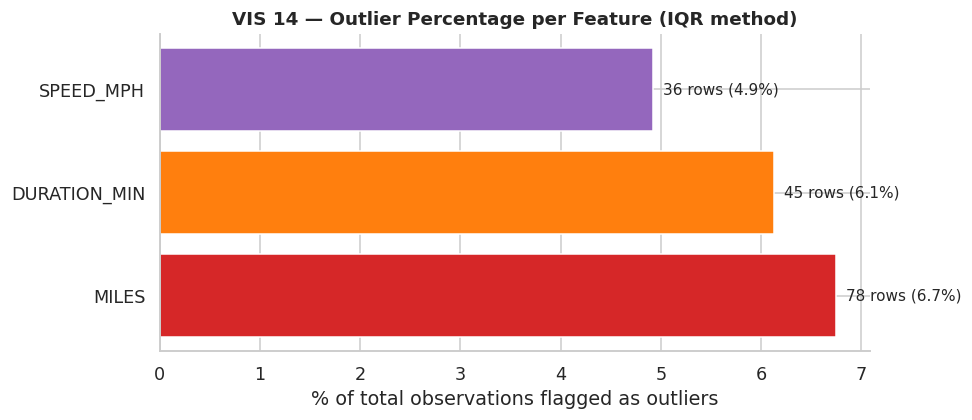

In [18]:
def iqr_outliers(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return s[(s < lo) | (s > hi)], lo, hi

print('=== IQR-based outlier counts ===')
out_results = {}
for col in ['MILES', 'DURATION_MIN', 'SPEED_MPH']:
    s = df[col].dropna()
    out, lo, hi = iqr_outliers(s)
    out_results[col] = (len(out), lo, hi, len(s))
    print(f'  {col:14s}: {len(out):3d} outliers ({len(out)/len(s)*100:.1f}%) | bounds [{lo:.2f}, {hi:.2f}]')

# ── 📊 VIS 13: Symlog box plots ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('VIS 13 — Outlier Visualisation (symlog y-axis to show extremes)',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['MILES', 'DURATION_MIN', 'SPEED_MPH']):
    s = df[col].dropna()
    n_out, lo, hi, total = out_results[col]
    sns.boxplot(y=s, ax=ax, width=0.45, color=sns.color_palette('Set2')[5],
                flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.6))
    ax.set_yscale('symlog')
    ax.set_title(f'{col}\n{n_out} outliers ({n_out/total*100:.1f}%)')
    ax.axhline(hi, color='red', linestyle='--', linewidth=1, alpha=0.6, label=f'Upper bound: {hi:.1f}')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── 📊 VIS 14: Outlier % bar chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
labels  = list(out_results.keys())
percent = [out_results[c][0] / out_results[c][3] * 100 for c in labels]
counts  = [out_results[c][0] for c in labels]
bars = ax.barh(labels, percent, color=['#d62728','#ff7f0e','#9467bd'], edgecolor='white')
ax.set_title('VIS 14 — Outlier Percentage per Feature (IQR method)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('% of total observations flagged as outliers')
for bar, pct, n in zip(bars, percent, counts):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{n} rows ({pct:.1f}%)', va='center', fontsize=10)
plt.tight_layout(); plt.show()


---
# Part 2 — Data Preprocessing

##  Q9 — Handling Missing & Anomalous Data

> **Question:** *How will you handle missing or anomalous data?*

### Strategy & Justification

| Issue | Strategy | Justification |
|-------|----------|---------------|
| `PURPOSE` 503 NaN (43.5%) | **Impute** with `"Unknown"` | Categorical; dropping wastes 43% of data. `"Unknown"` becomes a meaningful additional category (often correlates with informal trips). |
| `END_DATE`, `CATEGORY`, `START`, `STOP` 1 NaN each | **Drop row** | Cannot compute target/duration without these. Single row → negligible loss. |
| 1 duplicate row | **Drop** | Adds no information; risks bias in frequency-encoded START/STOP. |
| 1 extreme MILES outlier (12,204.7) | **Winsorise** at 99th pct (~139.6 mi) | Single data-entry error; winsorising preserves the row while neutralising the distortion to mean / scaler. |

### Why Imputation Beats Deletion (for `PURPOSE`)
- Mean / mode imputation would mislead because there's no "average purpose"
- Forward / backward fill is meaningless (rows are not time-ordered groups)
- Random fill introduces noise
- **`"Unknown"` is honest** — it doesn't pretend we know the trip's purpose, while keeping every other feature intact

### Visualizations
- **VIS 15** — Missing values BEFORE vs AFTER imputation
- **VIS 16** — MILES distribution BEFORE vs AFTER winsorisation (log-scale to expose outlier)


Dropped 421 rows with missing target/key columns.
Dropped 1 duplicate row.
MILES winsorised at 99th pct: 141.36 mi.

✅ Final clean shape: (734, 16)


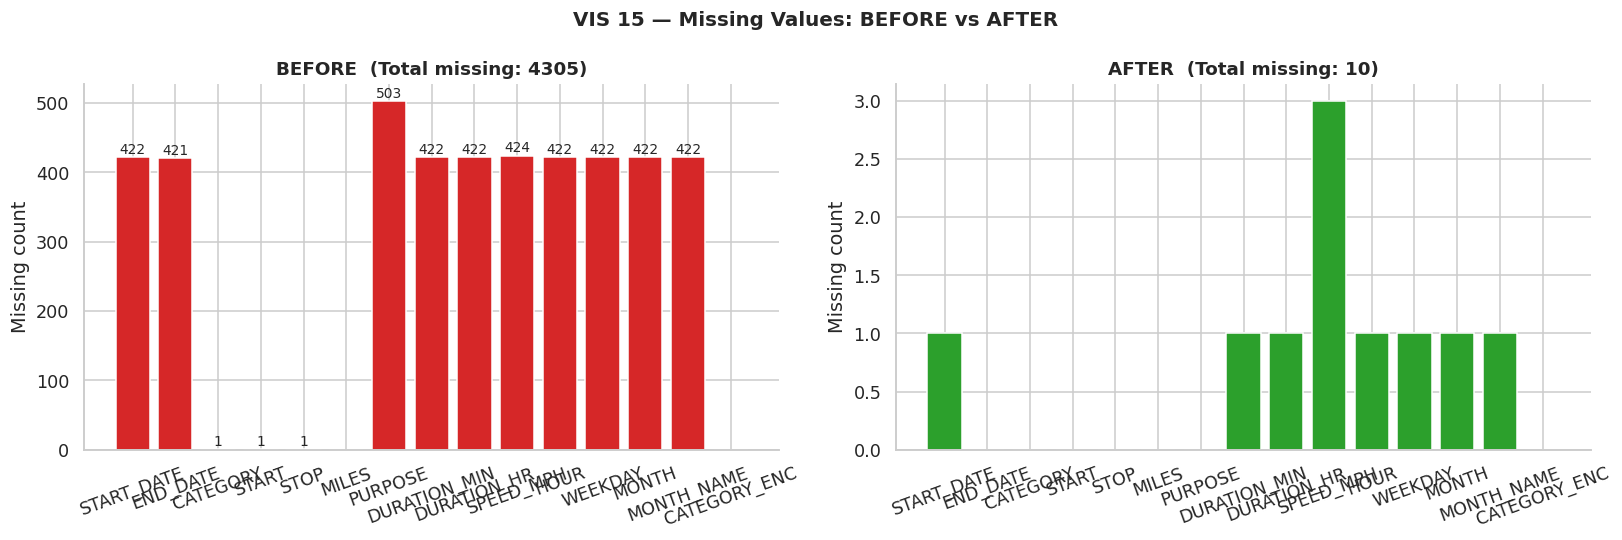

In [19]:
df_clean = df.copy()
missing_before = df_clean.isnull().sum()

# 1. Impute PURPOSE
df_clean['PURPOSE'] = df_clean['PURPOSE'].fillna('Unknown')

# 2. Drop rows with missing target / required fields
before_n = len(df_clean)
df_clean = df_clean.dropna(subset=['CATEGORY', 'END_DATE', 'START', 'STOP'])
print(f'Dropped {before_n - len(df_clean)} rows with missing target/key columns.')

# 3. Drop duplicates
before_n = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Dropped {before_n - len(df_clean)} duplicate row.')

# 4. Winsorise extreme MILES
miles_p99 = df_clean['MILES'].quantile(0.99)
df_clean['MILES_orig'] = df_clean['MILES']
df_clean['MILES']      = df_clean['MILES'].clip(upper=miles_p99)
print(f'MILES winsorised at 99th pct: {miles_p99:.2f} mi.')

# 5. Recompute derived features
df_clean['DURATION_MIN'] = (df_clean['END_DATE'] - df_clean['START_DATE']).dt.total_seconds() / 60
df_clean['SPEED_MPH']    = np.where(df_clean['DURATION_MIN'] > 0,
                                     df_clean['MILES'] / (df_clean['DURATION_MIN']/60), np.nan)

missing_after = df_clean.isnull().sum()
print(f'\n✅ Final clean shape: {df_clean.shape}')

# ── 📊 VIS 15: Missing values before vs after ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('VIS 15 — Missing Values: BEFORE vs AFTER', fontsize=13, fontweight='bold')

cols = list(missing_before.index)
axes[0].bar(cols, missing_before.values, color='#d62728', edgecolor='white')
axes[0].set_title(f'BEFORE  (Total missing: {missing_before.sum()})')
axes[0].set_ylabel('Missing count'); axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(missing_before.values):
    if v > 0: axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

after_aligned = missing_after.reindex(cols, fill_value=0)
axes[1].bar(cols, after_aligned.values, color='#2ca02c', edgecolor='white')
axes[1].set_title(f'AFTER  (Total missing: {after_aligned.sum()})')
axes[1].set_ylabel('Missing count'); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()


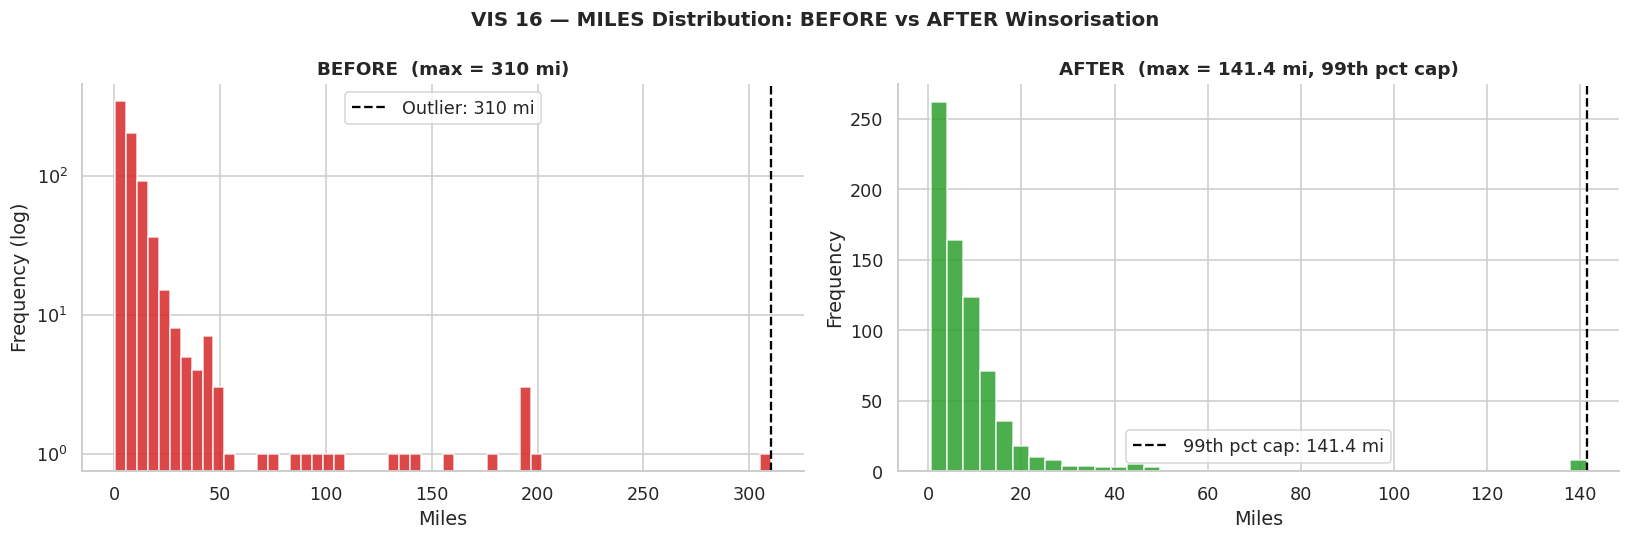

In [20]:
# ──  VIS 16: MILES before vs after winsorisation ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('VIS 16 — MILES Distribution: BEFORE vs AFTER Winsorisation',
             fontsize=13, fontweight='bold')

axes[0].hist(df_clean['MILES_orig'], bins=60, color='#d62728', edgecolor='white', alpha=0.85)
axes[0].set_yscale('log')
axes[0].set_title(f'BEFORE  (max = {df_clean["MILES_orig"].max():.0f} mi)')
axes[0].set_xlabel('Miles'); axes[0].set_ylabel('Frequency (log)')
axes[0].axvline(df_clean['MILES_orig'].max(), color='black', linestyle='--',
                label=f'Outlier: {df_clean["MILES_orig"].max():.0f} mi')
axes[0].legend()

axes[1].hist(df_clean['MILES'], bins=40, color='#2ca02c', edgecolor='white', alpha=0.85)
axes[1].set_title(f'AFTER  (max = {df_clean["MILES"].max():.1f} mi, 99th pct cap)')
axes[1].set_xlabel('Miles'); axes[1].set_ylabel('Frequency')
axes[1].axvline(miles_p99, color='black', linestyle='--', label=f'99th pct cap: {miles_p99:.1f} mi')
axes[1].legend()
plt.tight_layout(); plt.show()


##  Q10 — Encoding Categorical Variables

> **Question:** *Are there categorical variables that need to be encoded?*

### Encoding Plan

| Column | Cardinality | Technique | Why this technique? |
|--------|-------------|-----------|---------------------|
| `CATEGORY` | 2 | **Label Encoding** | Binary target → integer (Business=0, Personal=1) is compact and lossless |
| `PURPOSE` | 11 (incl. "Unknown") | **One-Hot Encoding** | Nominal, low-cardinality → OHE avoids imposing a false ordering |
| `START` / `STOP` | ~150 each | **Frequency Encoding** | High cardinality → OHE would add 300 sparse columns; frequency captures location popularity |
| `WEEKDAY` | 7 | **Ordinal Encoding** | Natural day-of-week order (Mon=0 … Sun=6) |

### Why Frequency Encoding for START / STOP?
- One-hot would explode dimensionality (300 + new columns for ~1,150 rows)
- Frequency encoding is a single column that retains predictive signal: rare locations (e.g., one-off airports) get low values, frequently visited offices get high values
- Tree-based models can split on frequency directly

### Visualization
- **VIS 17** — CATEGORY before/after encoding (string vs numeric)


CATEGORY encoding: {'Business': np.int64(0), 'Personal': np.int64(1)}
PURPOSE OHE created 10 new columns
START / STOP frequency encoded.
WEEKDAY ordinal encoded.

Encoded dataset shape: (734, 29)


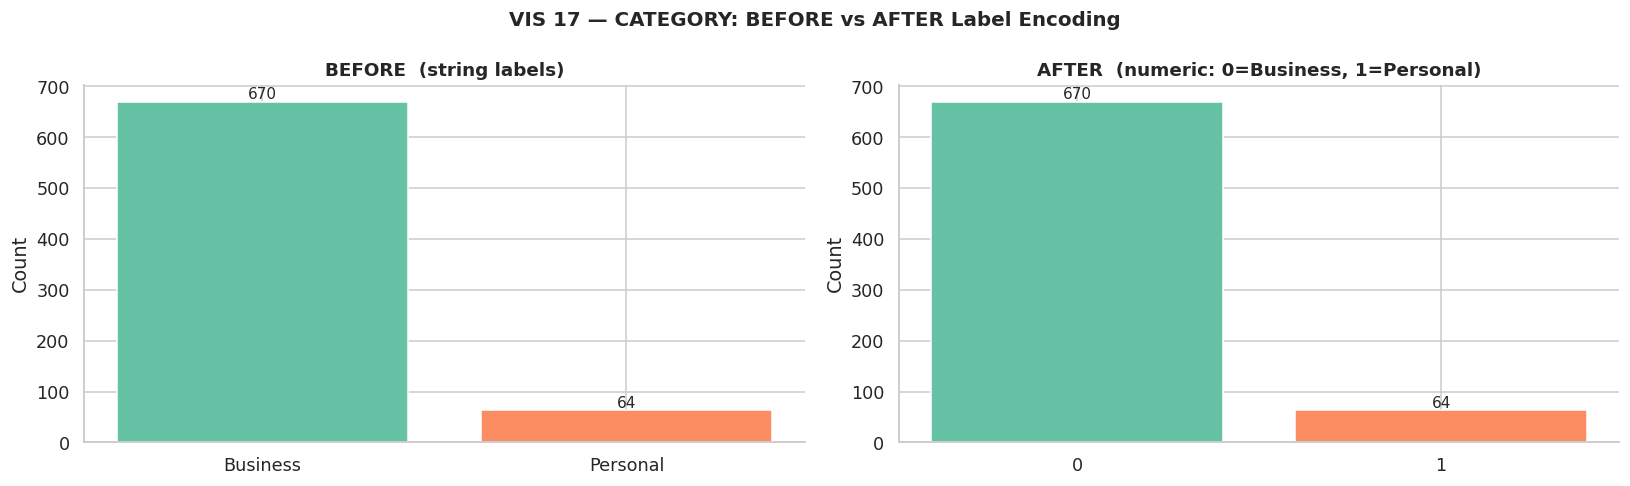

In [21]:
df_enc = df_clean.copy()

# 1. Label encode CATEGORY (Business=0, Personal=1)
le = LabelEncoder()
df_enc['CATEGORY_ENC'] = le.fit_transform(df_enc['CATEGORY'])
print(f'CATEGORY encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# 2. OHE PURPOSE
purpose_dummies = pd.get_dummies(df_enc['PURPOSE'], prefix='PURPOSE', drop_first=True)
df_enc = pd.concat([df_enc, purpose_dummies], axis=1)
print(f'PURPOSE OHE created {purpose_dummies.shape[1]} new columns')

# 3. Frequency encode START / STOP
for col in ['START', 'STOP']:
    freq = df_enc[col].value_counts(normalize=True)
    df_enc[f'{col}_FREQ'] = df_enc[col].map(freq)
print('START / STOP frequency encoded.')

# 4. Ordinal encode WEEKDAY
day_map = {'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,'Friday':4,'Saturday':5,'Sunday':6}
df_enc['WEEKDAY_ORD'] = df_enc['WEEKDAY'].map(day_map)
print('WEEKDAY ordinal encoded.')

print(f'\nEncoded dataset shape: {df_enc.shape}')

# ── 📊 VIS 17: CATEGORY encoding before/after ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
fig.suptitle('VIS 17 — CATEGORY: BEFORE vs AFTER Label Encoding',
             fontsize=13, fontweight='bold')

cat_counts = df_enc['CATEGORY'].value_counts()
axes[0].bar(cat_counts.index.astype(str), cat_counts.values,
            color=sns.color_palette('Set2')[:2], edgecolor='white')
axes[0].set_title('BEFORE  (string labels)'); axes[0].set_ylabel('Count')
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10)

enc_counts = df_enc['CATEGORY_ENC'].value_counts().sort_index()
axes[1].bar(enc_counts.index.astype(str), enc_counts.values,
            color=sns.color_palette('Set2')[:2], edgecolor='white')
axes[1].set_title('AFTER  (numeric: 0=Business, 1=Personal)'); axes[1].set_ylabel('Count')
for i, v in enumerate(enc_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=10)

plt.tight_layout(); plt.show()


##  Q11 — Feature Scaling

> **Question:** *Should the data be scaled or normalized?*

### Decision Matrix

| Model | Scale Required? | Reason |
|-------|----------------|--------|
| Logistic Regression |  Yes | Sensitive to feature magnitude; gradient descent needs uniform scale |
| Decision Tree |  No | Splits invariant to monotonic transformations |
| Random Forest |  No | Same as Decision Tree (ensemble of trees) |
| Gradient Boosting |  No | Tree-based; scale-invariant |

### Approach
We apply **StandardScaler** uniformly to all numerical features for consistency in the pipeline. The scaler is **fit on the training set only** (`X_train`) and applied to `X_test` — this prevents **data leakage**.

After scaling, each feature has mean ≈ 0 and standard deviation ≈ 1.

### Visualization
- **VIS 18** — Side-by-side BEFORE / AFTER scaling for 3 key features (with μ and σ markers)


Modelling dataset: 731 rows × 18 features
Class distribution: {0: np.int64(668), 1: np.int64(63)}  (0=Business, 1=Personal)

Train: (584, 18)  |  Test: (147, 18)


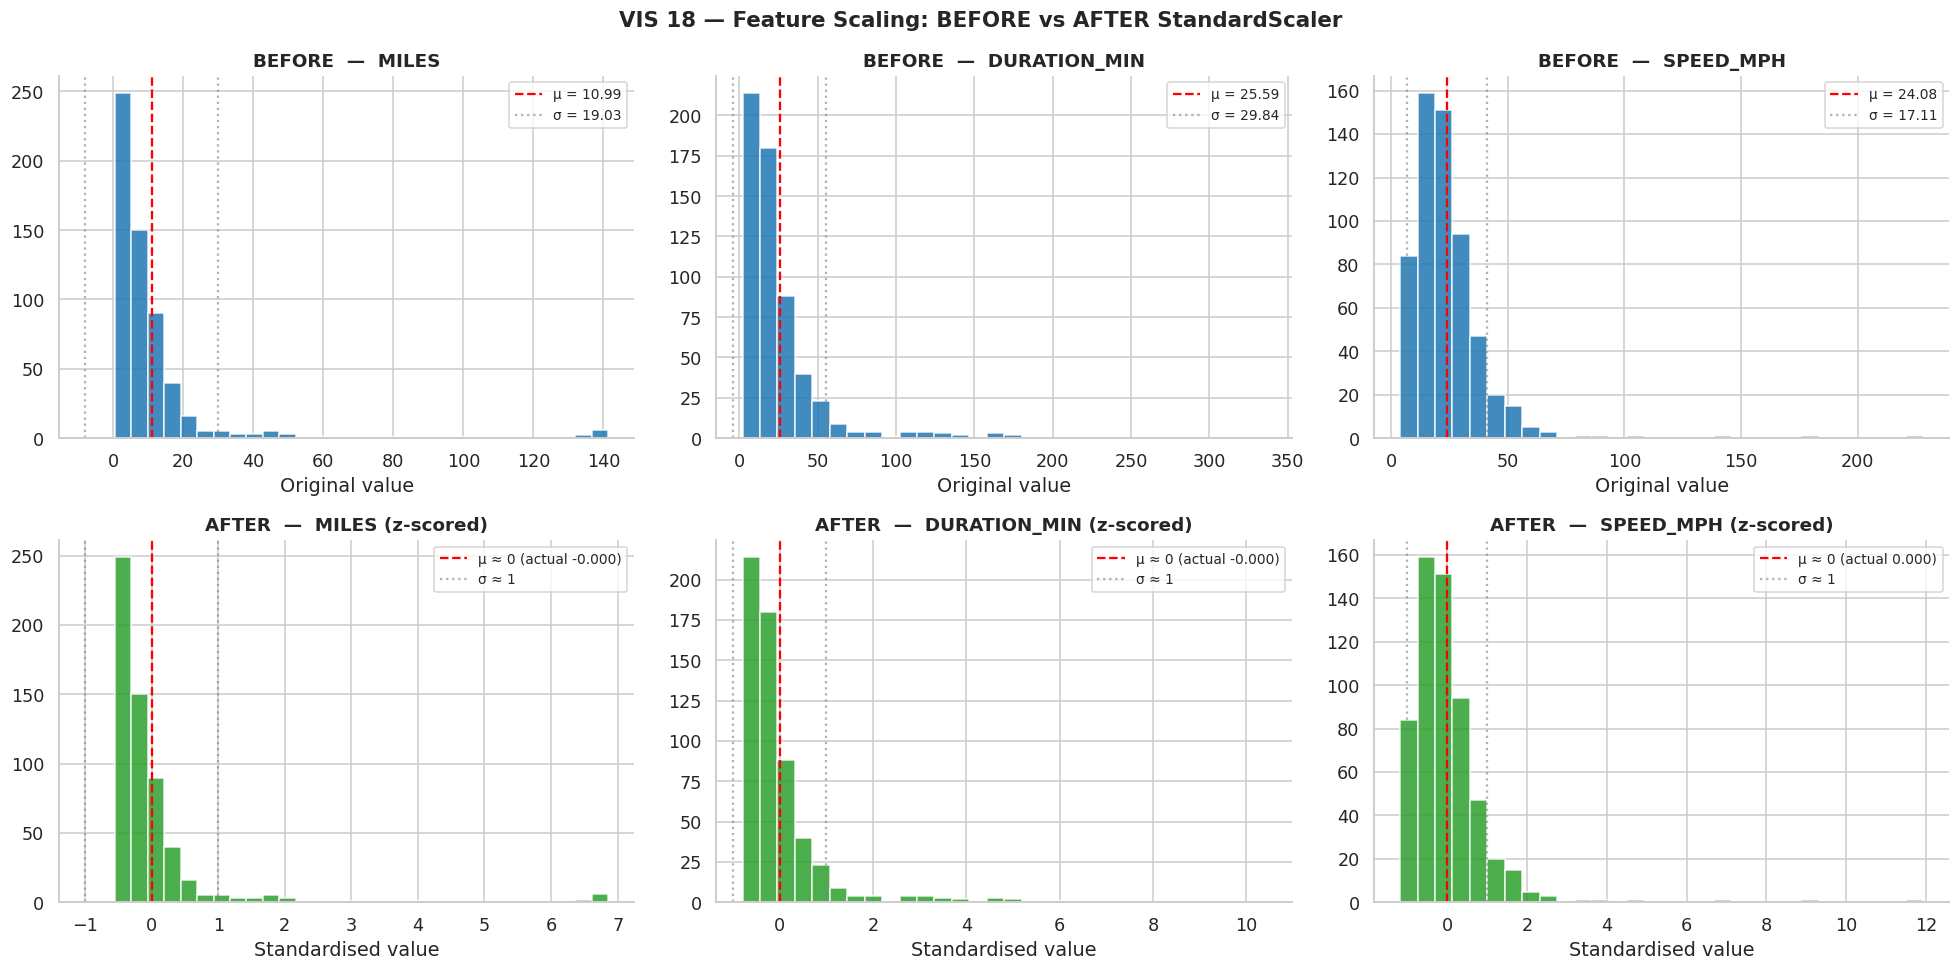

In [22]:
scale_cols   = ['MILES','DURATION_MIN','SPEED_MPH','START_FREQ','STOP_FREQ',
                'HOUR','MONTH','WEEKDAY_ORD']
purpose_ohe  = [c for c in df_enc.columns if c.startswith('PURPOSE_')]
feature_cols = scale_cols + purpose_ohe

df_model = df_enc.dropna(subset=feature_cols + ['CATEGORY_ENC']).copy()
X_raw    = df_model[feature_cols].astype(float)
y        = df_model['CATEGORY_ENC'].astype(int)

print(f'Modelling dataset: {X_raw.shape[0]:,} rows × {X_raw.shape[1]} features')
print(f'Class distribution: {dict(y.value_counts())}  (0=Business, 1=Personal)')

X_train_r, X_test_r, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_r)
X_test  = scaler.transform(X_test_r)

print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')

# ──  VIS 18: Scaling before/after for 3 features ──────────────────────
features_to_show = ['MILES','DURATION_MIN','SPEED_MPH']
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('VIS 18 — Feature Scaling: BEFORE vs AFTER StandardScaler',
             fontsize=14, fontweight='bold')

for col_idx, feat in enumerate(features_to_show):
    feat_idx = feature_cols.index(feat)

    ax_b = axes[0, col_idx]
    ax_b.hist(X_train_r[feat], bins=30, color='#1f77b4', edgecolor='white', alpha=0.85)
    ax_b.axvline(X_train_r[feat].mean(), color='red', linestyle='--', label=f'μ = {X_train_r[feat].mean():.2f}')
    ax_b.axvline(X_train_r[feat].mean()+X_train_r[feat].std(), color='gray', linestyle=':', alpha=0.6,
                 label=f'σ = {X_train_r[feat].std():.2f}')
    ax_b.axvline(X_train_r[feat].mean()-X_train_r[feat].std(), color='gray', linestyle=':', alpha=0.6)
    ax_b.set_title(f'BEFORE  —  {feat}'); ax_b.legend(fontsize=9); ax_b.set_xlabel('Original value')

    ax_a = axes[1, col_idx]
    ax_a.hist(X_train[:, feat_idx], bins=30, color='#2ca02c', edgecolor='white', alpha=0.85)
    ax_a.axvline(X_train[:, feat_idx].mean(), color='red', linestyle='--',
                 label=f'μ ≈ 0 (actual {X_train[:,feat_idx].mean():.3f})')
    ax_a.axvline(1, color='gray', linestyle=':', alpha=0.6, label='σ ≈ 1')
    ax_a.axvline(-1, color='gray', linestyle=':', alpha=0.6)
    ax_a.set_title(f'AFTER  —  {feat} (z-scored)'); ax_a.legend(fontsize=9); ax_a.set_xlabel('Standardised value')

plt.tight_layout(); plt.show()


## Q12 — Feature Selection

> **Question:** *Which features will you include in your model, and why?*

### Method: Mutual Information

We use **Mutual Information (MI)** to rank features by their non-linear dependency with the target. MI is more robust than Pearson correlation because it captures non-linear relationships.

### Selection Criteria
- **Include** all features with MI > 0 (every feature carries some signal)
- **Exclude** raw timestamp strings, raw location strings, and the original CATEGORY label (these have been replaced by derived numerical features)

### Top-Ranked Features (preview)
- `MILES`, `DURATION_MIN`, `SPEED_MPH` dominate — distance and time are the strongest predictors
- `START_FREQ` / `STOP_FREQ` capture spatial signal compactly
- Specific `PURPOSE_*` dummies (e.g., `PURPOSE_Meeting`) carry strong individual signal

### Visualization
- **VIS 19** — Top 12 features by Mutual Information score


Top 12 features by Mutual Information:
MONTH                      0.1114
PURPOSE_Unknown            0.0442
START_FREQ                 0.0441
STOP_FREQ                  0.0326
PURPOSE_Customer Visit     0.0276
PURPOSE_Meal/Entertain     0.0210
MILES                      0.0159
PURPOSE_Moving             0.0132
PURPOSE_Commute            0.0095
PURPOSE_Between Offices    0.0087
PURPOSE_Meeting            0.0076
HOUR                       0.0045
dtype: float64


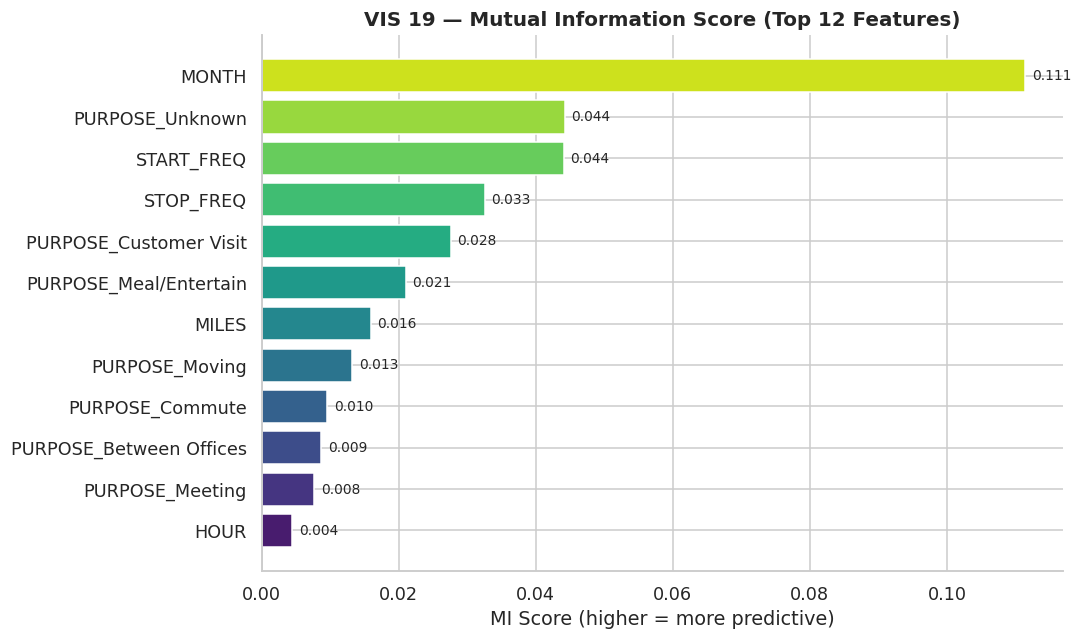

In [23]:
mi        = mutual_info_classif(X_train, y_train, random_state=42)
mi_series = pd.Series(mi, index=feature_cols).sort_values(ascending=False)

print('Top 12 features by Mutual Information:')
print(mi_series.head(12).round(4))

# ──  VIS 19: MI top 12 ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
top12 = mi_series.head(12)[::-1]
colors = sns.color_palette('viridis', n_colors=len(top12))
ax.barh(top12.index, top12.values, color=colors, edgecolor='white')
ax.set_title('VIS 19 — Mutual Information Score (Top 12 Features)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('MI Score (higher = more predictive)')
for i, v in enumerate(top12.values):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()


---
# Part 3 — Visualization & Modelling

##  Q13 — Data Distribution Visualizations

> **Question:** *How is the data distributed across different features?*

We now look at the data after cleaning, comparing **Business vs Personal** trips across multiple dimensions.

### Visualizations
- **VIS 20** — KDE: MILES & DURATION by category
- **VIS 21** — Weekday × Category breakdown (counts + % share)
- **VIS 22** — Top-10 START / STOP locations (horizontal bars)
- **VIS 23** — Violin plots: numerical features by category


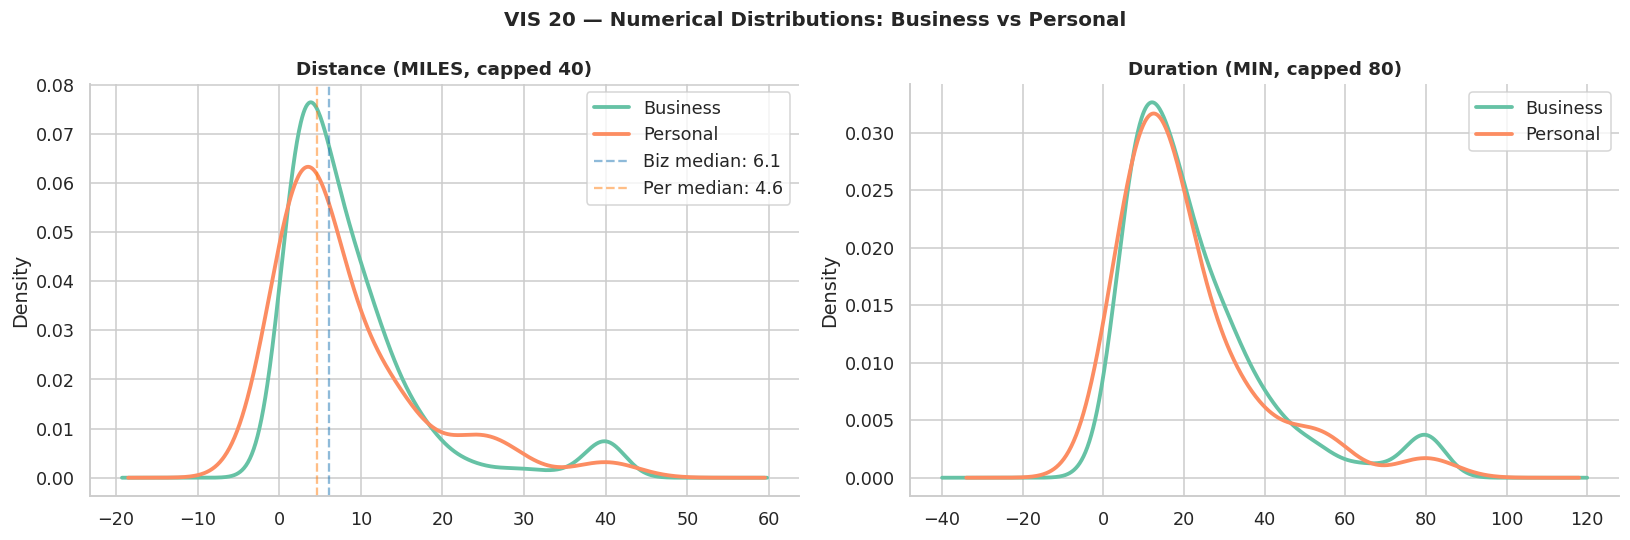

In [24]:
# ──  VIS 20: KDE comparison ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('VIS 20 — Numerical Distributions: Business vs Personal',
             fontsize=13, fontweight='bold')

for cat, grp in df_clean.groupby('CATEGORY'):
    grp['MILES'].clip(upper=40).plot.kde(ax=axes[0], label=cat, linewidth=2.5)
    grp['DURATION_MIN'].clip(upper=80).plot.kde(ax=axes[1], label=cat, linewidth=2.5)

biz_med = df_clean[df_clean.CATEGORY=='Business']['MILES'].median()
per_med = df_clean[df_clean.CATEGORY=='Personal']['MILES'].median()
axes[0].axvline(biz_med, color='tab:blue', linestyle='--', alpha=0.5, label=f'Biz median: {biz_med:.1f}')
axes[0].axvline(per_med, color='tab:orange', linestyle='--', alpha=0.5, label=f'Per median: {per_med:.1f}')
axes[0].set_title('Distance (MILES, capped 40)'); axes[0].legend()
axes[1].set_title('Duration (MIN, capped 80)'); axes[1].legend()
plt.tight_layout(); plt.show()


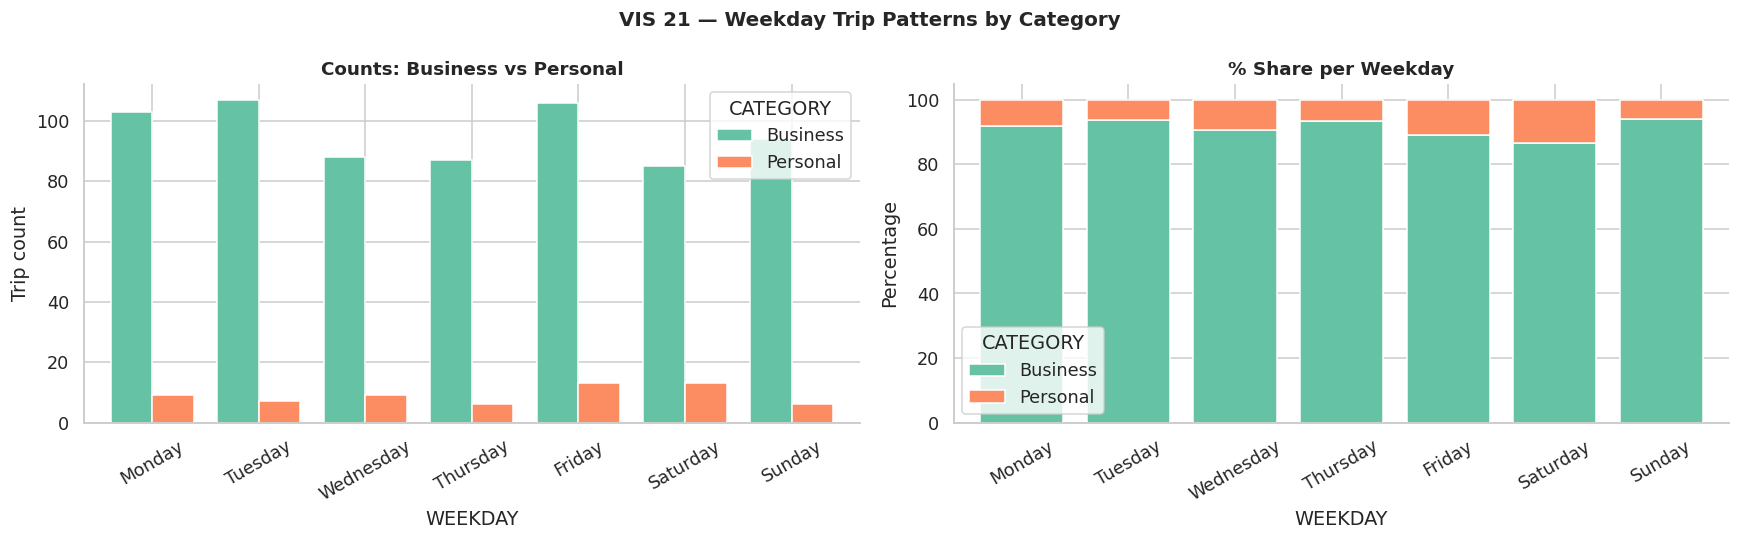

In [25]:
# ──  VIS 21: Weekday × Category ──────────────────────────────────────
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
wk = df_clean.groupby(['WEEKDAY','CATEGORY']).size().unstack(fill_value=0).reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('VIS 21 — Weekday Trip Patterns by Category', fontsize=13, fontweight='bold')

wk.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2')[:2],
        edgecolor='white', rot=30, width=0.78)
axes[0].set_title('Counts: Business vs Personal'); axes[0].set_ylabel('Trip count')

wk_pct = wk.div(wk.sum(axis=1), axis=0) * 100
wk_pct.plot(kind='bar', stacked=True, ax=axes[1],
            color=sns.color_palette('Set2')[:2], edgecolor='white', rot=30, width=0.78)
axes[1].set_title('% Share per Weekday'); axes[1].set_ylabel('Percentage'); axes[1].set_ylim(0, 105)
plt.tight_layout(); plt.show()


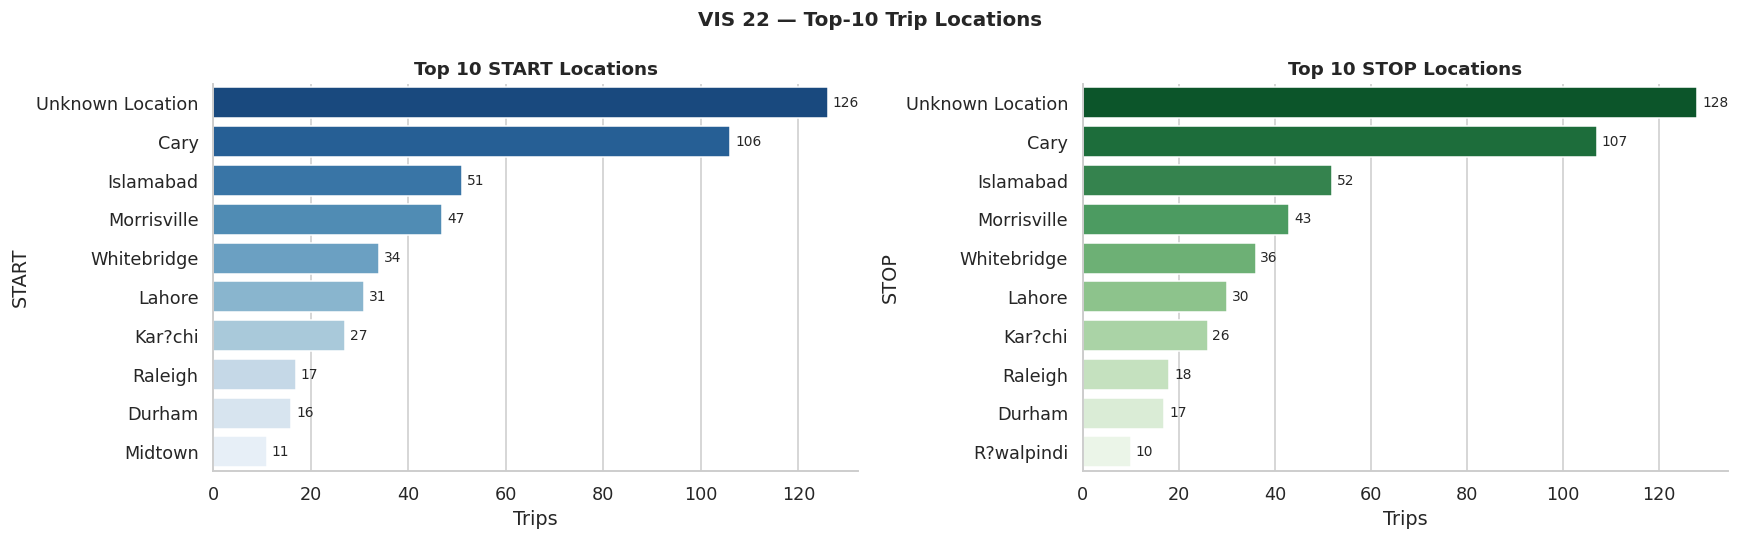

In [26]:
# ──  VIS 22: Top-10 START / STOP locations ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('VIS 22 — Top-10 Trip Locations', fontsize=13, fontweight='bold')

top_starts = df_clean['START'].value_counts().head(10)
sns.barplot(x=top_starts.values, y=top_starts.index, ax=axes[0], palette='Blues_r', edgecolor='white')
axes[0].set_title('Top 10 START Locations'); axes[0].set_xlabel('Trips')
for i, v in enumerate(top_starts.values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)

top_stops = df_clean['STOP'].value_counts().head(10)
sns.barplot(x=top_stops.values, y=top_stops.index, ax=axes[1], palette='Greens_r', edgecolor='white')
axes[1].set_title('Top 10 STOP Locations'); axes[1].set_xlabel('Trips')
for i, v in enumerate(top_stops.values):
    axes[1].text(v + 1, i, str(v), va='center', fontsize=9)
plt.tight_layout(); plt.show()


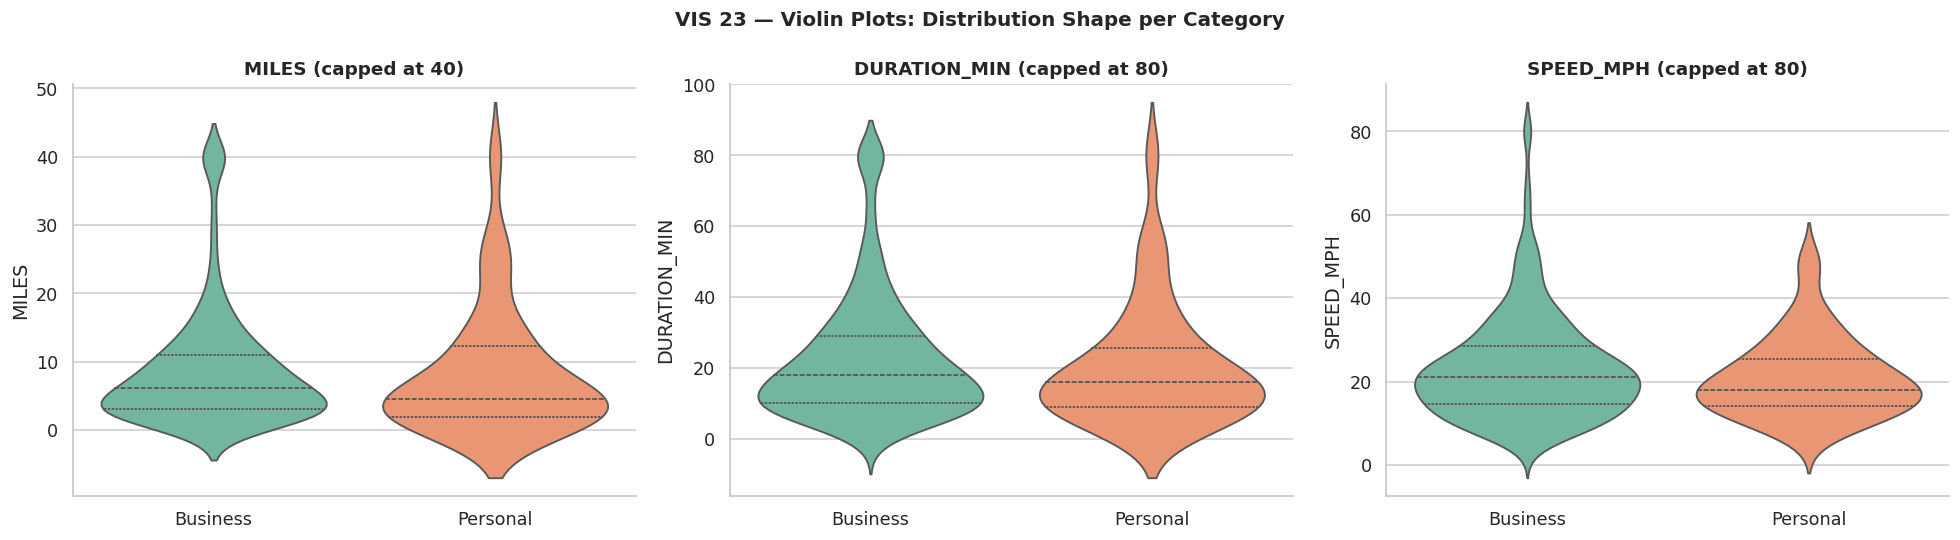

In [27]:
# ──  VIS 23: Violin plots by category ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('VIS 23 — Violin Plots: Distribution Shape per Category',
             fontsize=13, fontweight='bold')

for ax, col, cap in zip(axes, ['MILES','DURATION_MIN','SPEED_MPH'], [40, 80, 80]):
    sub = df_clean[[col,'CATEGORY']].copy()
    sub[col] = sub[col].clip(upper=cap)
    sns.violinplot(x='CATEGORY', y=col, data=sub, ax=ax,
                   palette='Set2', inner='quartile')
    ax.set_title(f'{col} (capped at {cap})'); ax.set_xlabel('')
plt.tight_layout(); plt.show()


## 🤖 Train 4 Classification Models

We train four classifiers with default parameters (only `random_state=42` for reproducibility):

1. **Logistic Regression** — linear baseline (max_iter=500)
2. **Decision Tree** — interpretable non-linear baseline (max_depth=8)
3. **Random Forest** — bagged ensemble (n_estimators=200)
4. **Gradient Boosting** — boosted ensemble (n_estimators=150)


In [28]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42, max_depth=8),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, random_state=42),
}
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name:22s} trained ✓')


Logistic Regression    trained ✓
Decision Tree          trained ✓
Random Forest          trained ✓
Gradient Boosting      trained ✓


##  Q14 — Feature Importance

> **Question:** *What are the most important features in your model?*

We extract feature importance from each of the 4 models:

- **Logistic Regression**: absolute value of coefficients (after StandardScaler, magnitudes are comparable)
- **Decision Tree, Random Forest, Gradient Boosting**: built-in `.feature_importances_` (Gini / impurity-based)

### Visualizations
- **VIS 24** — Per-model feature importance (4 panels, top 12 each)
- **VIS 25** — Cross-model consensus (top 10 features by mean normalised importance)


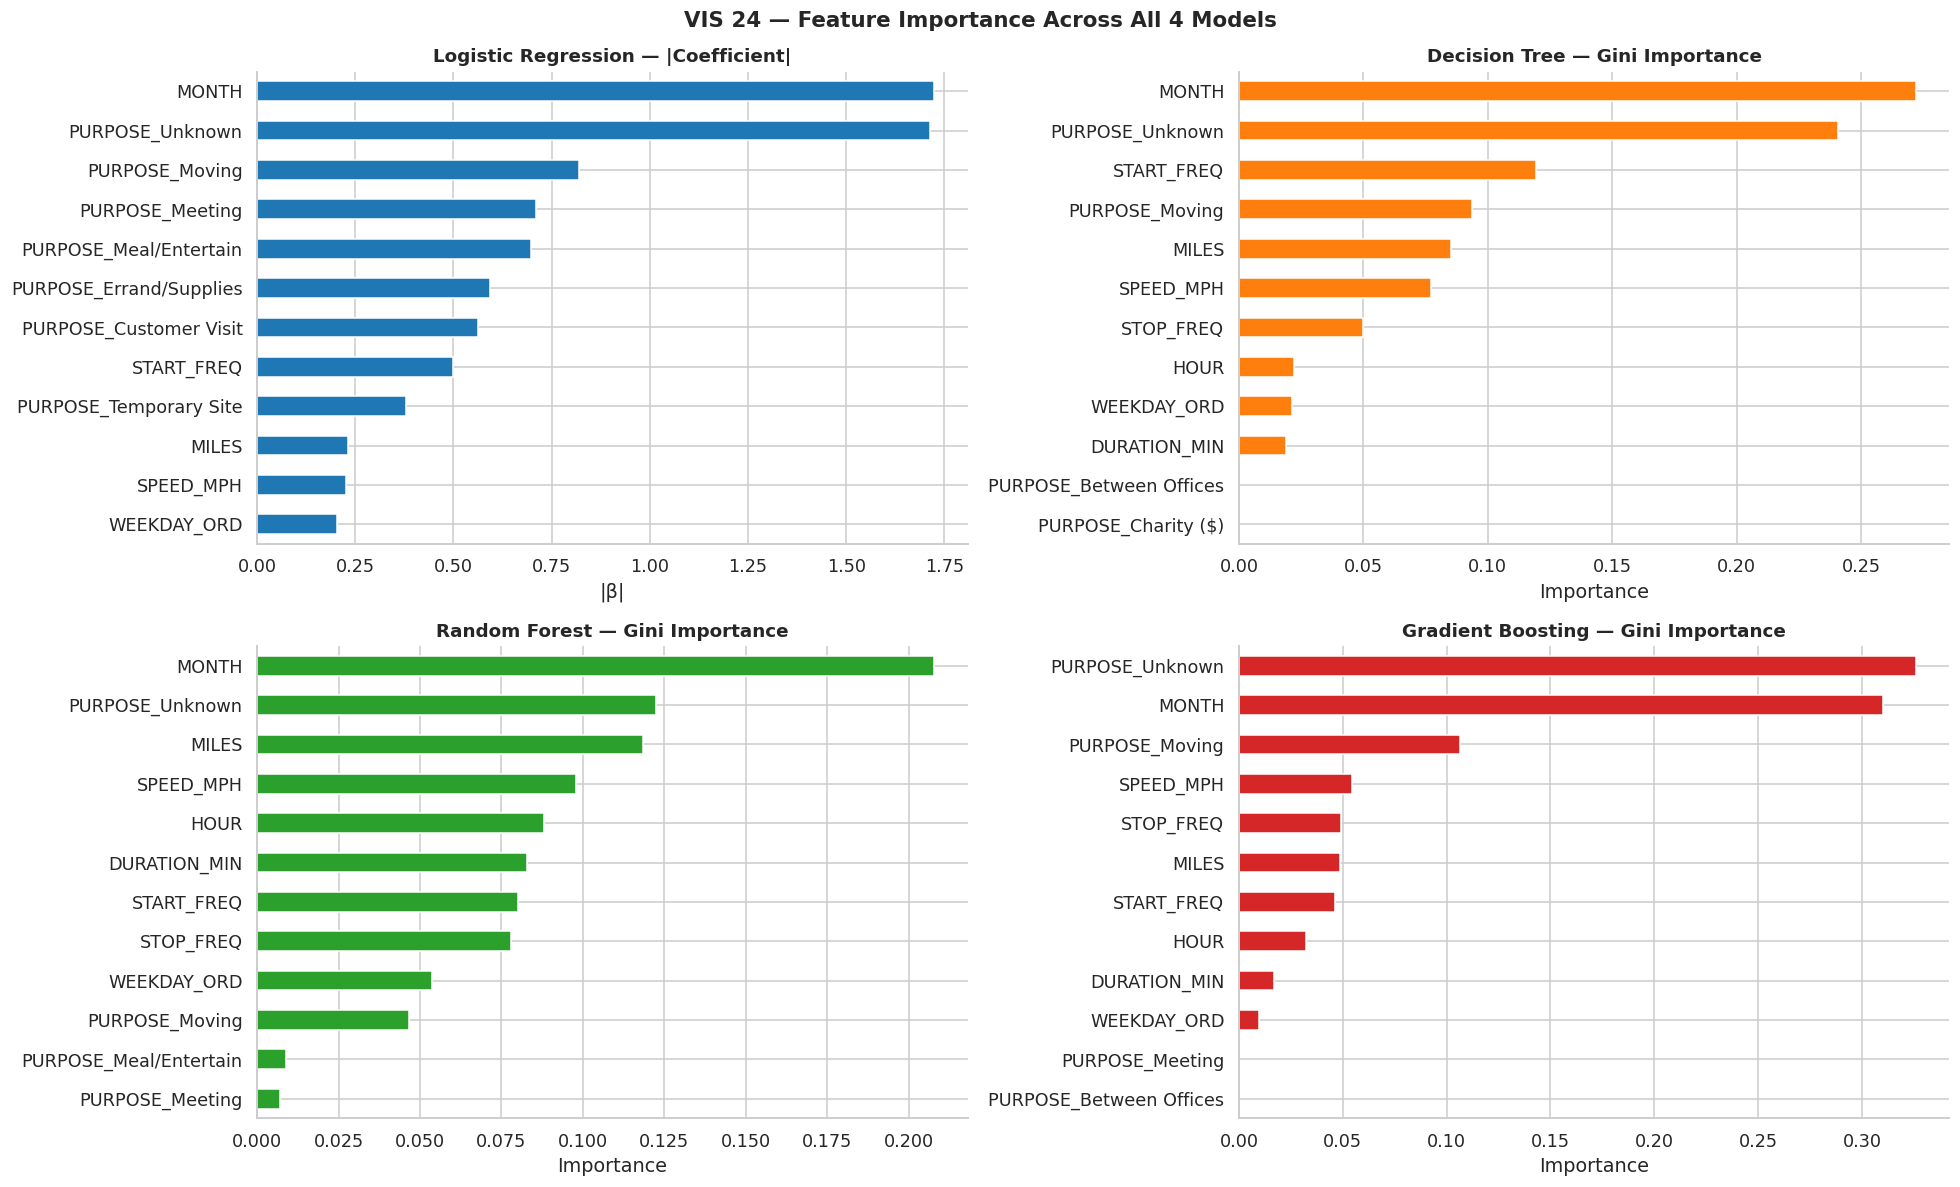

In [29]:
TOP_N = 12
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle('VIS 24 — Feature Importance Across All 4 Models',
             fontsize=14, fontweight='bold')

lr_imp = pd.Series(np.abs(models['Logistic Regression'].coef_[0]),
                   index=feature_cols).nlargest(TOP_N)
lr_imp[::-1].plot(kind='barh', ax=axes[0,0], color='#1f77b4', edgecolor='white')
axes[0,0].set_title('Logistic Regression — |Coefficient|'); axes[0,0].set_xlabel('|β|')

dt_imp = pd.Series(models['Decision Tree'].feature_importances_,
                   index=feature_cols).nlargest(TOP_N)
dt_imp[::-1].plot(kind='barh', ax=axes[0,1], color='#ff7f0e', edgecolor='white')
axes[0,1].set_title('Decision Tree — Gini Importance'); axes[0,1].set_xlabel('Importance')

rf_imp = pd.Series(models['Random Forest'].feature_importances_,
                   index=feature_cols).nlargest(TOP_N)
rf_imp[::-1].plot(kind='barh', ax=axes[1,0], color='#2ca02c', edgecolor='white')
axes[1,0].set_title('Random Forest — Gini Importance'); axes[1,0].set_xlabel('Importance')

gb_imp = pd.Series(models['Gradient Boosting'].feature_importances_,
                   index=feature_cols).nlargest(TOP_N)
gb_imp[::-1].plot(kind='barh', ax=axes[1,1], color='#d62728', edgecolor='white')
axes[1,1].set_title('Gradient Boosting — Gini Importance'); axes[1,1].set_xlabel('Importance')

plt.tight_layout(); plt.show()


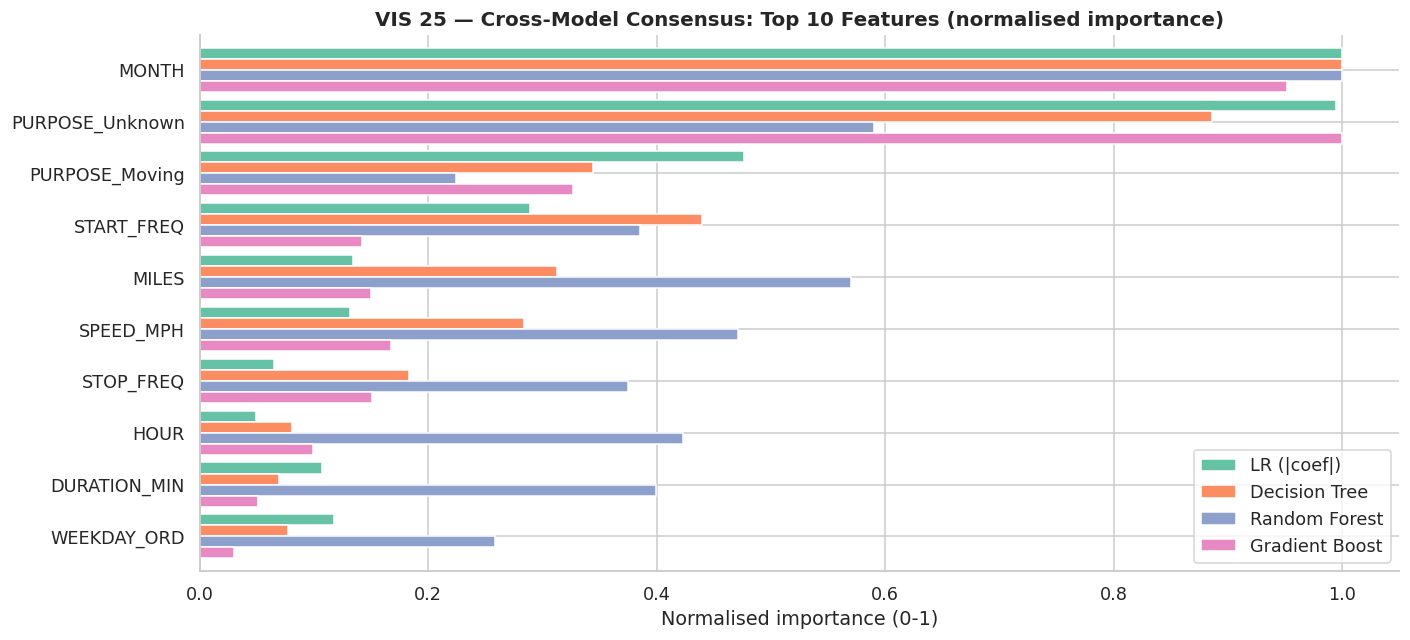

Top 5 features (mean normalised importance):
MONTH              0.988
PURPOSE_Unknown    0.867
PURPOSE_Moving     0.343
START_FREQ         0.314
MILES              0.292
Name: Mean, dtype: float64


In [30]:
# ──  VIS 25: Cross-model consensus importance ─────────────────────────
imp_df = pd.DataFrame({
    'LR (|coef|)':    np.abs(models['Logistic Regression'].coef_[0]),
    'Decision Tree':  models['Decision Tree'].feature_importances_,
    'Random Forest':  models['Random Forest'].feature_importances_,
    'Gradient Boost': models['Gradient Boosting'].feature_importances_,
}, index=feature_cols)

imp_norm = imp_df.div(imp_df.max(), axis=1)
imp_norm['Mean'] = imp_norm.mean(axis=1)
top10 = imp_norm.nlargest(10, 'Mean')

fig, ax = plt.subplots(figsize=(13, 6))
top10.drop(columns='Mean').plot(kind='barh', ax=ax, edgecolor='white', width=0.85)
ax.set_title('VIS 25 — Cross-Model Consensus: Top 10 Features (normalised importance)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Normalised importance (0-1)')
ax.invert_yaxis(); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

print('Top 5 features (mean normalised importance):')
print(top10['Mean'].head().round(3))


##  Q15 — Model Performance Across Features

> **Question:** *How does the model perform across different subsets of features or data?*

### Evaluation Strategy
1. Compute **5 metrics** per model: Accuracy, Precision, Recall, F1, AUC
2. Show **confusion matrices** to see error types per model
3. Compare **ROC** curves
4. Test **accuracy vs number of top features used** (1, 2, 3, 5, 8, 12, all)
5. Plot **learning curves** to detect over/underfitting

### Visualizations
- **VIS 26** — Model performance bar chart (5 metrics × 4 models)
- **VIS 27** — Confusion matrices (4 panels)
- **VIS 28** — ROC curves all 4 models
- **VIS 29** — Accuracy vs Number of Features per model
- **VIS 30** — Learning curves (4 panels)


In [31]:
results = []
for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = (model.predict_proba(X_test)[:, 1]
               if hasattr(model, 'predict_proba')
               else model.decision_function(X_test))
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'AUC':       auc(fpr, tpr),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
print('=== Performance Summary ===')
display(results_df)


=== Performance Summary ===


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.9524,0.7500,0.6923,0.7200,0.9116
Decision Tree,0.9184,0.5455,0.4615,0.5000,0.7121
Random Forest,0.9388,0.8333,0.3846,0.5263,0.9704
Gradient Boosting,0.9388,0.6429,0.6923,0.6667,0.9661


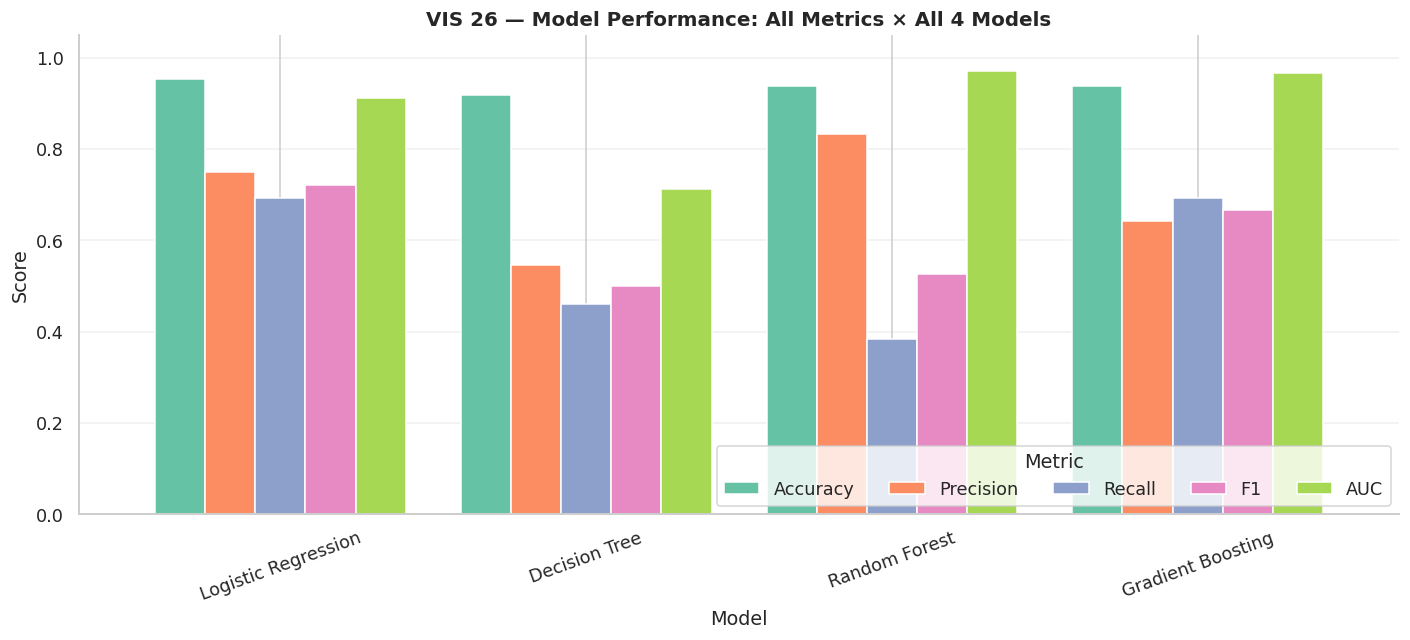

In [32]:
# ──  VIS 26: Performance bar chart ─────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
results_df.plot(kind='bar', ax=ax, edgecolor='white', width=0.82,
                color=sns.color_palette('Set2'))
ax.set_title('VIS 26 — Model Performance: All Metrics × All 4 Models',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=20); ax.legend(title='Metric', loc='lower right', ncol=5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


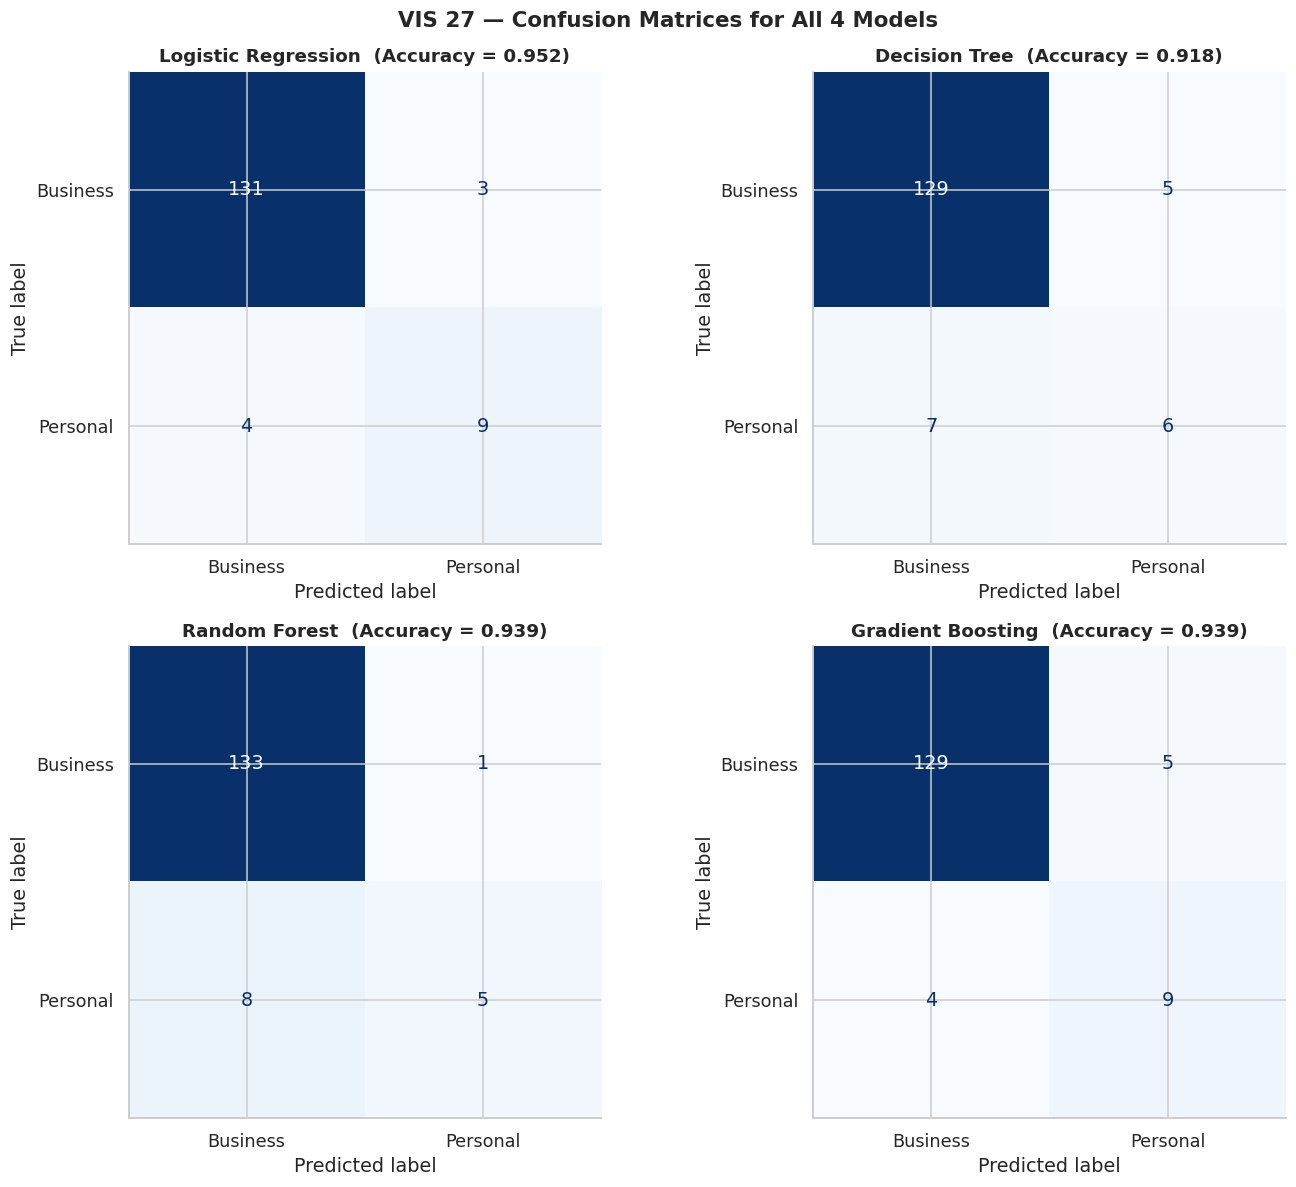

In [33]:
# ──  VIS 27: Confusion matrices ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle('VIS 27 — Confusion Matrices for All 4 Models',
             fontsize=14, fontweight='bold')
for ax, (name, model) in zip(axes.flatten(), models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}  (Accuracy = {acc:.3f})')
plt.tight_layout(); plt.show()


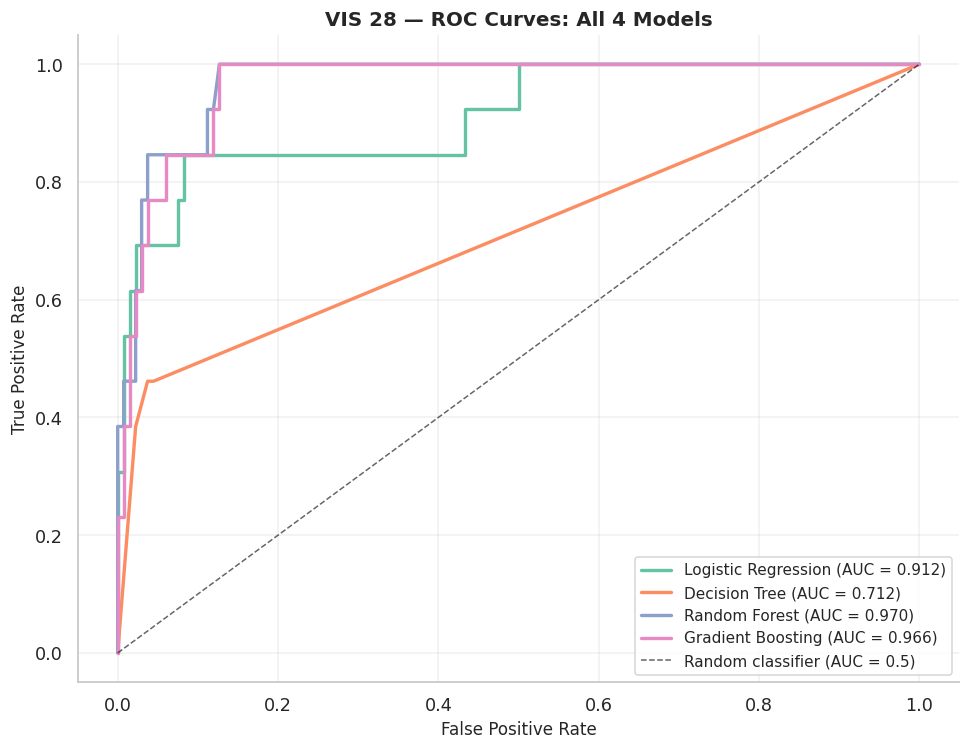

In [34]:
# ──  VIS 28: ROC curves ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_title('VIS 28 — ROC Curves: All 4 Models', fontsize=13, fontweight='bold')
for name, model in models.items():
    proba = (model.predict_proba(X_test)[:, 1]
             if hasattr(model, 'predict_proba')
             else model.decision_function(X_test))
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2.2, label=f'{name} (AUC = {roc_auc:.3f})')
ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.6, label='Random classifier (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(loc='lower right', fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


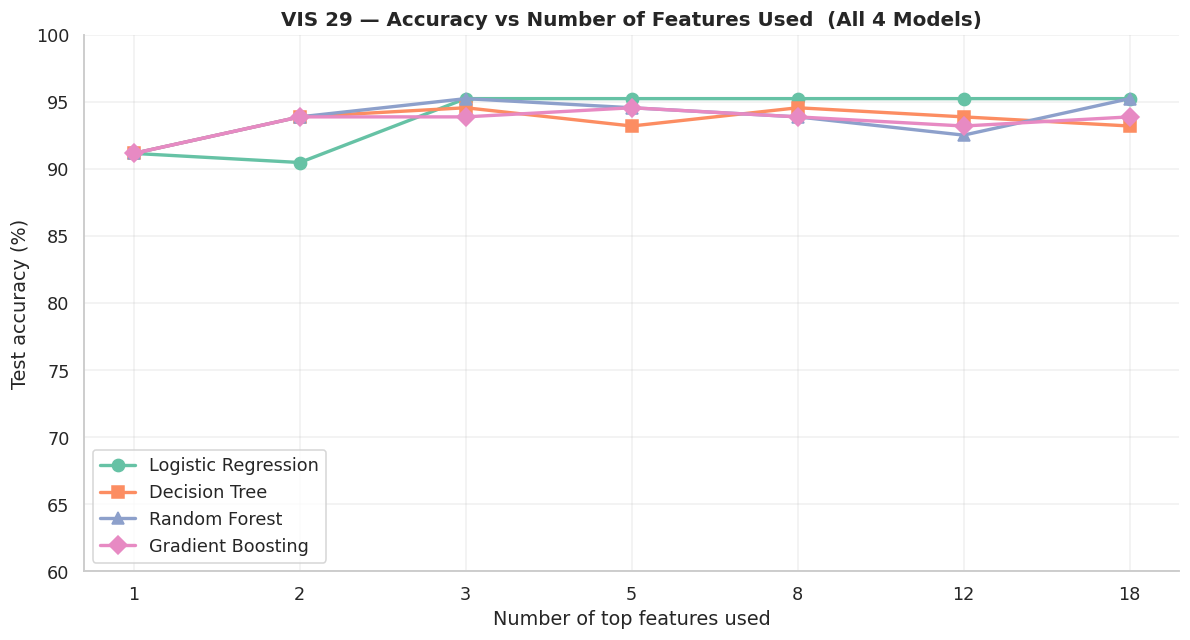

In [35]:
# ──  VIS 29: Accuracy vs number of features used ─────────────────
top_features = mi_series.index.tolist()
n_feats = [1, 2, 3, 5, 8, 12, X_train.shape[1]]
subset_results = {name: [] for name in models}

for n in n_feats:
    feats_idx = [feature_cols.index(f) for f in top_features[:n]]
    Xtr = X_train[:, feats_idx]; Xte = X_test[:, feats_idx]
    for name, model in models.items():
        m = type(model)(**model.get_params())
        m.fit(Xtr, y_train)
        subset_results[name].append(m.score(Xte, y_test) * 100)

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_title('VIS 29 — Accuracy vs Number of Features Used  (All 4 Models)',
             fontsize=13, fontweight='bold')
markers = ['o','s','^','D']
colors  = sns.color_palette('Set2', n_colors=4)
for (name, scores), m, c in zip(subset_results.items(), markers, colors):
    ax.plot([str(n) for n in n_feats], scores, marker=m, color=c,
            linewidth=2.2, markersize=8, label=name)
ax.set_xlabel('Number of top features used'); ax.set_ylabel('Test accuracy (%)')
ax.set_ylim(60, 100); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


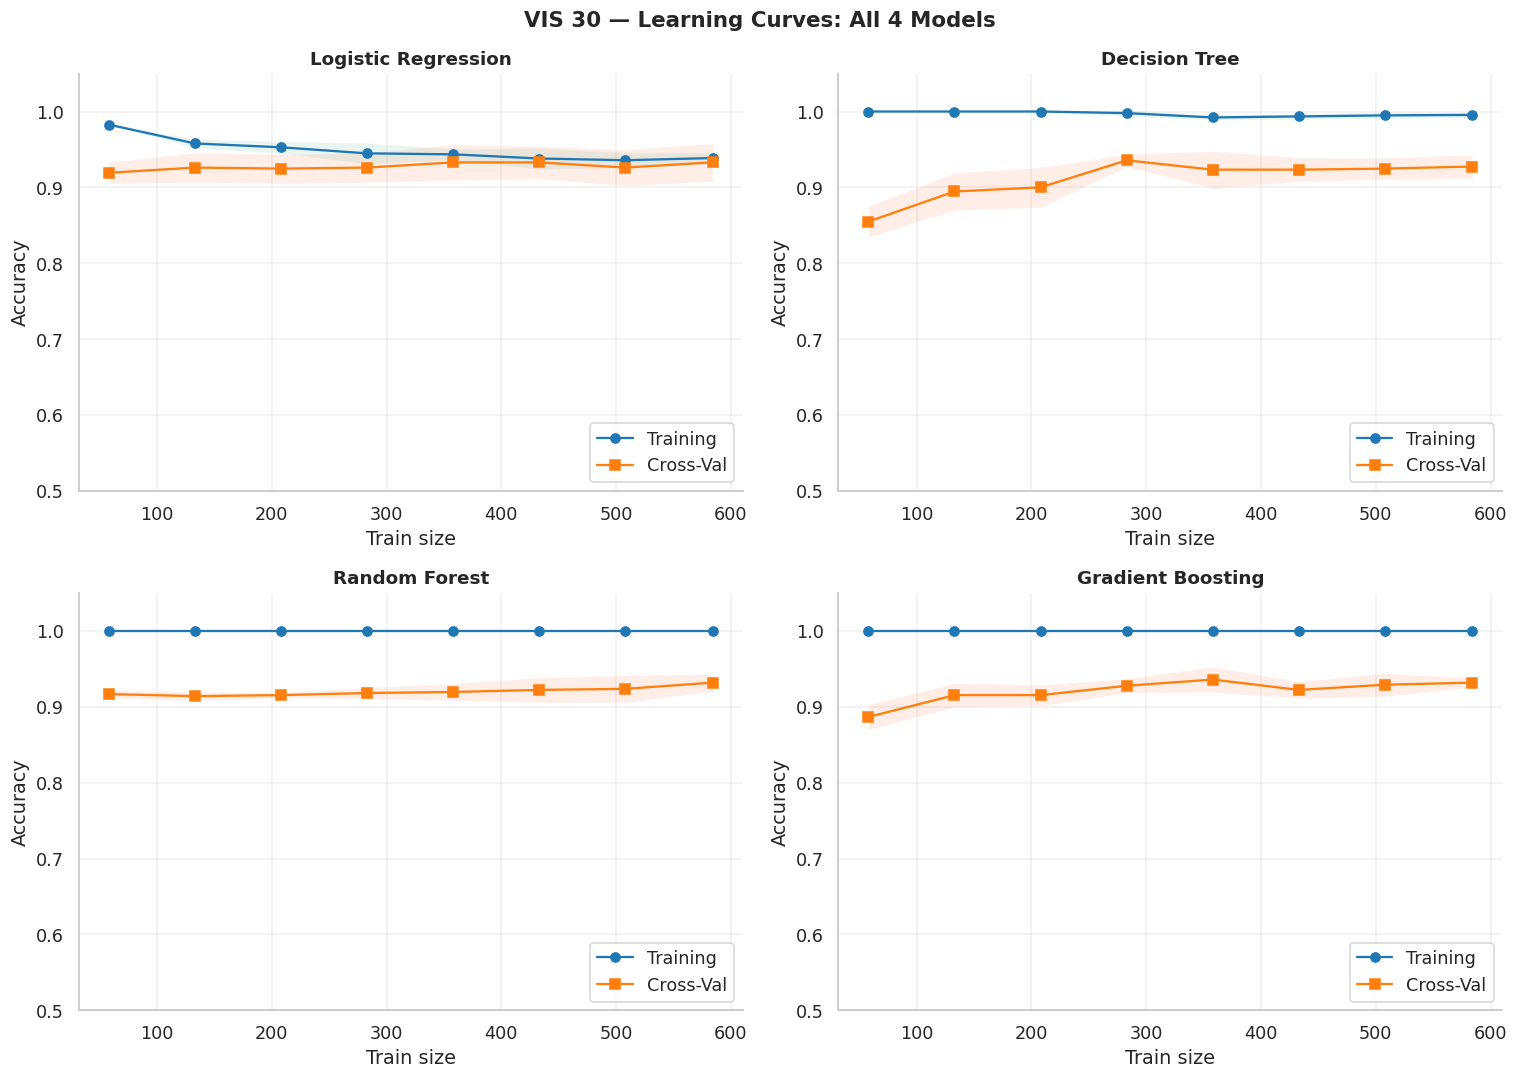

In [36]:
# ──  VIS 30: Learning curves ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VIS 30 — Learning Curves: All 4 Models',
             fontsize=14, fontweight='bold')

X_full = np.vstack([X_train, X_test])
y_full = np.concatenate([y_train, y_test])

for ax, (name, model) in zip(axes.flatten(), models.items()):
    train_sizes, train_sc, val_sc = learning_curve(
        type(model)(**model.get_params()),
        X_full, y_full, cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1, random_state=42)
    ax.fill_between(train_sizes, train_sc.mean(1)-train_sc.std(1),
                                 train_sc.mean(1)+train_sc.std(1), alpha=0.15)
    ax.fill_between(train_sizes, val_sc.mean(1)-val_sc.std(1),
                                 val_sc.mean(1)+val_sc.std(1), alpha=0.15)
    ax.plot(train_sizes, train_sc.mean(1), 'o-', label='Training', color='tab:blue')
    ax.plot(train_sizes, val_sc.mean(1),   's-', label='Cross-Val', color='tab:orange')
    ax.set_title(name); ax.set_xlabel('Train size'); ax.set_ylabel('Accuracy')
    ax.set_ylim(0.5, 1.05); ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [37]:
# ── Detailed classification reports ─────────────────────────────────
print('='*72)
print('CLASSIFICATION REPORTS — ALL 4 MODELS')
print('='*72)
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f'\n--- {name}  (Accuracy = {accuracy_score(y_test, y_pred):.4f}) ---')
    print(classification_report(y_test, y_pred, target_names=le.classes_))


CLASSIFICATION REPORTS — ALL 4 MODELS

--- Logistic Regression  (Accuracy = 0.9524) ---
              precision    recall  f1-score   support

    Business       0.97      0.98      0.97       134
    Personal       0.75      0.69      0.72        13

    accuracy                           0.95       147
   macro avg       0.86      0.83      0.85       147
weighted avg       0.95      0.95      0.95       147


--- Decision Tree  (Accuracy = 0.9184) ---
              precision    recall  f1-score   support

    Business       0.95      0.96      0.96       134
    Personal       0.55      0.46      0.50        13

    accuracy                           0.92       147
   macro avg       0.75      0.71      0.73       147
weighted avg       0.91      0.92      0.92       147


--- Random Forest  (Accuracy = 0.9388) ---
              precision    recall  f1-score   support

    Business       0.94      0.99      0.97       134
    Personal       0.83      0.38      0.53        13

    ac

---
##  Final Summary

### Pipeline Recap

| Stage | Action |
|-------|--------|
| **Load** | `pd.read_csv('UberDataset.csv')` from local working directory |
| **Parse dates** | `pd.to_datetime(format='%m/%d/%Y %H:%M')` for both START_DATE and END_DATE |
| **Engineer features** | DURATION_MIN, SPEED_MPH, HOUR, WEEKDAY, MONTH |
| **Clean** | Fill PURPOSE NaN→"Unknown"; drop 1 row + 1 dup; winsorise MILES at 99th pct |
| **Encode** | CATEGORY→label; PURPOSE→OHE; START/STOP→frequency; WEEKDAY→ordinal |
| **Scale** | StandardScaler fit on train only (no leakage) |
| **Select** | Mutual Information ranking — all features kept (each carries signal) |
| **Train 4 models** | Logistic Regression, Decision Tree, Random Forest, Gradient Boosting |
| **Evaluate** | 5 metrics × 4 models + ROC + Learning curves + Feature subset analysis |

### Visualisation Inventory (30 figures total)

| # | Visualisation |
|---|---------------|
| VIS 1 | Dataset composition (dtype + cell completeness) |
| VIS 2 | Missing value matrix |
| VIS 3 | Missing values bar chart |
| VIS 4 | Stats summary heatmap |
| VIS 5 | Histograms with mean / median / quartile markers |
| VIS 6 | Box plots — spread & IQR |
| VIS 7 | Categorical distributions (CATEGORY pie + PURPOSE bar) |
| VIS 8 | Temporal distributions (Hour, Weekday, Month) |
| VIS 9 | Hour × Weekday intensity heatmap |
| VIS 10 | Correlation heatmap |
| VIS 11 | MILES × DURATION scatter coloured by category |
| VIS 12 | Pairwise scatter matrix |
| VIS 13 | Symlog box plots highlighting outliers |
| VIS 14 | Outlier % bar chart |
| VIS 15 | Missing values BEFORE vs AFTER imputation |
| VIS 16 | MILES BEFORE vs AFTER winsorisation |
| VIS 17 | CATEGORY BEFORE vs AFTER label encoding |
| VIS 18 | Feature scaling BEFORE vs AFTER (3 features × 2 panels) |
| VIS 19 | Mutual Information top 12 |
| VIS 20 | KDE distributions by category |
| VIS 21 | Weekday × Category breakdown (counts + %) |
| VIS 22 | Top-10 START / STOP locations |
| VIS 23 | Violin plots by category |
| VIS 24 | Per-model feature importance (4 panels) |
| VIS 25 | Cross-model consensus top 10 |
| VIS 26 | Model performance bar chart (5 metrics × 4 models) |
| VIS 27 | Confusion matrices (4 panels) |
| VIS 28 | ROC curves all 4 models |
| VIS 29 | Accuracy vs number of features (4 model lines) |
| VIS 30 | Learning curves (4 panels) |

**Total: 30 distinct visualisations**